In [1]:
import numpy as np
import xarray
import os
from matplotlib import pyplot as plt
import scipy.signal as scipy_signal
import scipy.stats as scipy_stats
from geopy import distance as geo_dist
import cmocean
import pandas
import proplot
import cartopy.feature as cfeature
#from tcpyPI import pi, cape



/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/_collections_abc.py:841: MatplotlibDeprecationWarning: 
The examples.directory rcparam was deprecated in Matplotlib 3.0 and will be removed in 3.2. In the future, examples will be found relative to the 'datapath' directory.
  self[key] = other[key]


In [2]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '//tube1/cha674/Tropical_Turtles/pyPI/tcpyPI/src/tcpyPI')

#sys.path.append('//tube1/cha674/Tropical_Turtles/pyPI/tcpyPI/src/tcpyPI')
import pi as TCPI 



In [3]:
cyclone_list_file_name = '/tube1/cha674/Tropical_Turtles/turtle_storm_interaction.csv'
cyclone_list = pandas.read_csv(cyclone_list_file_name)
cyclone_list = cyclone_list.sort_values('date_storm_passage',ascending=True)
cyclone_list_filtered = cyclone_list.loc[cyclone_list['minimum_distance_km']<150]

In [4]:
cyclone_list_filtered

,Unnamed: 0,turtle_id,date_storm_passage,minimum_distance_km,storm_name
8,8,tu78-610-12_lr1_prof.nc,2013-02-27 06:11:15.000000,46.855911,Rusty
12,12,tu78-642-12_lr1_prof.nc,2013-11-23 20:20:37.500000,113.112067,Alessia
9,9,tu78-611-12_lr1_prof.nc,2013-12-30 11:40:18.750000,104.012000,Christine
4,4,tu120-615-22_hr1_prof.nc,2022-12-21 20:09:59.999998,19.061553,Ellie
1,1,tu120-619-22_hr1_prof.nc,2023-02-27 01:19:59.999996,99.069319,AU202223_16U
2,2,tu120-619-22_hr1_prof.nc,2023-04-10 00:30:00.000003,62.368129,Ilsa


In [4]:
cyclone_list_filtered  #tu120-615-22_hr1_prof.nc
storm_names = cyclone_list_filtered['storm_name']
storm_dates = cyclone_list_filtered['date_storm_passage']

In [27]:
cyclone_winds_turtle_path = '/tube1/cha674/Tropical_Turtles/cyclone_winds'

max_parametric_wind_speed = {}
for i_storm in storm_names:
    turtle_id = str(cyclone_list_filtered.loc[cyclone_list_filtered['storm_name']==i_storm]['turtle_id'].values[0])
    
    winds_file_name = i_storm + '_param_wind_speed_' + turtle_id
    
    wind_speed_dataset = xarray.open_dataset(os.path.join(cyclone_winds_turtle_path,winds_file_name))
    
    max_parametric_wind_speed[i_storm] = wind_speed_dataset['wnd_spd'].max().values.item()

    #if i_storm=='Ellie':
    #    das


In [6]:
max_parametric_wind_speed

{'Rusty': 28.742597937583923,
 'Alessia': 7.813300475478172,
 'Christine': 20.46975803375244,
 'Ellie': 11.25435034367307,
 'AU202223_16U': 13.14780457822376,
 'Ilsa': 14.151869296080765}

In [7]:
idx_start_storm = np.nonzero(wind_speed_dataset['wnd_spd'].values>0)[0][0]-1
idx_end_storm   = np.nonzero(wind_speed_dataset['wnd_spd'].values>0)[0][-1]+1

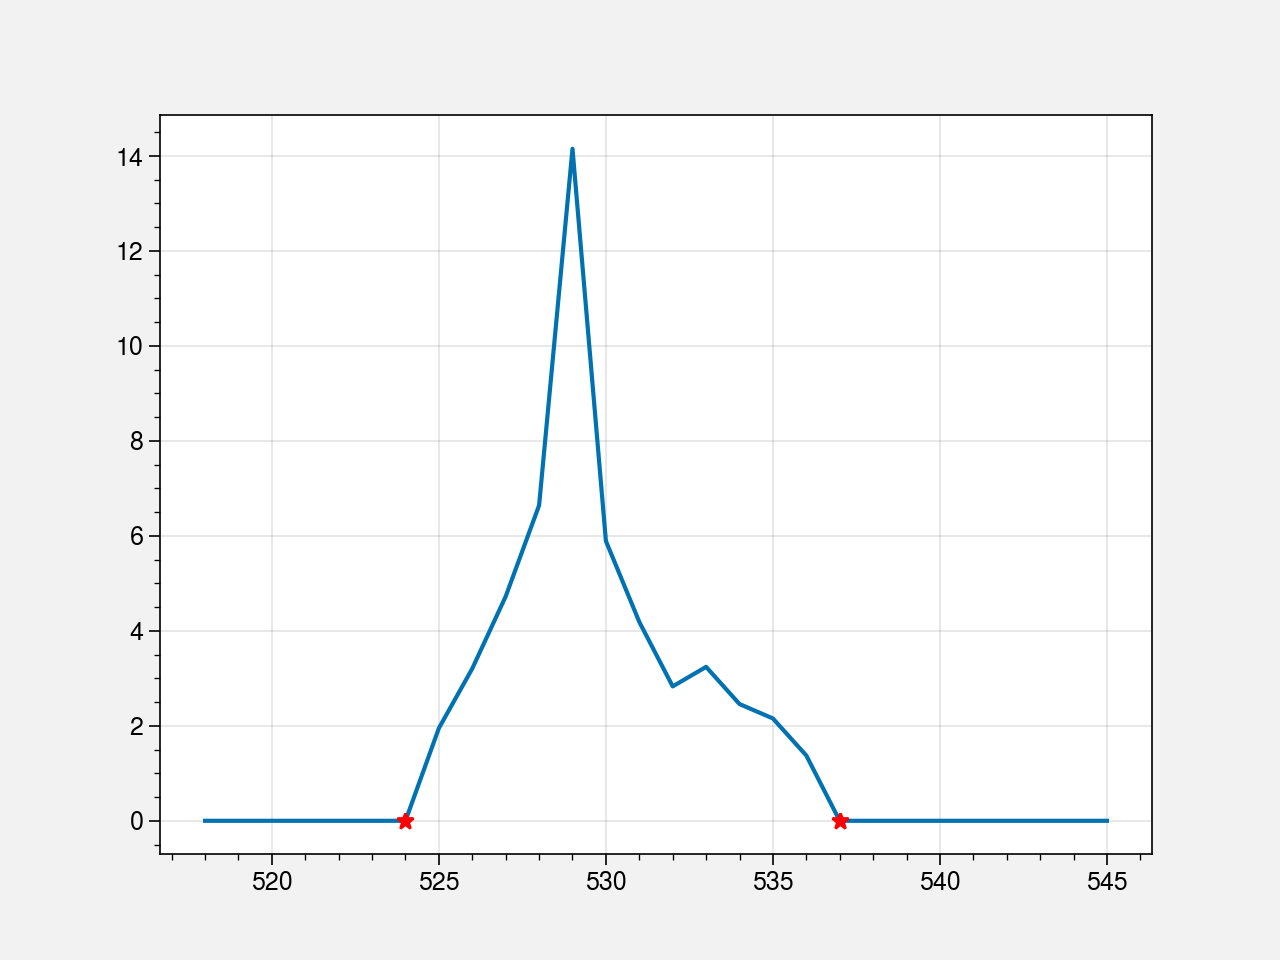

In [8]:
plt.plot(wind_speed_dataset['N_PROF'].values,wind_speed_dataset['wnd_spd'].values)
plt.plot(wind_speed_dataset['N_PROF'][idx_start_storm].values,wind_speed_dataset['wnd_spd'][idx_start_storm].values,'r*')
plt.plot(wind_speed_dataset['N_PROF'][idx_end_storm].values,wind_speed_dataset['wnd_spd'][idx_end_storm].values,'r*')


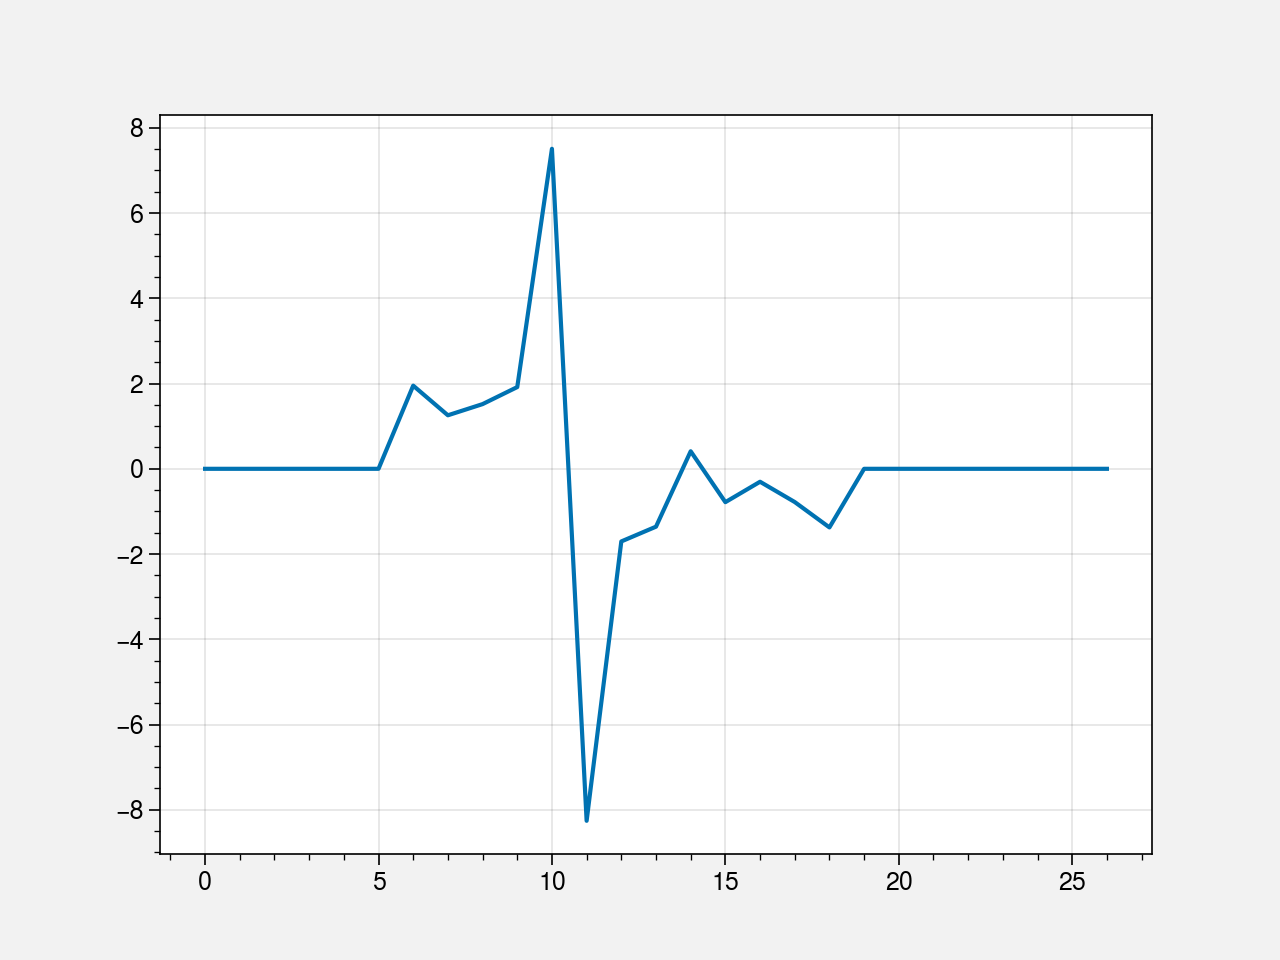

In [10]:

plt.plot(np.diff(wind_speed_dataset['wnd_spd']))

In [11]:
storm_wind_speed = wind_speed_dataset['wnd_spd']
idx_start_date = np.nonzero(storm_wind_speed.values>=1.0)[0][0]
storm_start_date = wind_speed_dataset['TIME'][idx_start_date]

pre_storm_dates = [storm_start_date.values-np.timedelta64(2,'D'),storm_start_date.values-np.timedelta64(1,'D')]

#plt.figure(1,figsize=(20,10))
#plt.plot(wind_speed_dataset['TIME'],wind_speed_dataset['wnd_spd'].values,'r*')

In [9]:
track_file_path = '/oa-decadal-climate/work/observations/Anibos_Turtles/IMOS_turtle_profiles_QC'
olive_ridley_dir = 'tu117'
flatback_dir     = 'tu120'


olive_ridley_files = os.listdir(os.path.join(track_file_path,olive_ridley_dir))
olive_ridley_files_list = []

for i_file in olive_ridley_files:
    
    if i_file.endswith('_hr1_prof.nc'):
        olive_ridley_files_list.append(os.path.join(track_file_path,olive_ridley_dir,i_file))
        

flatback_files = os.listdir(os.path.join(track_file_path,flatback_dir))
flatback_files_list = []

for i_file in flatback_files:
    
    if i_file.endswith('_hr1_prof.nc'):
        flatback_files_list.append(os.path.join(track_file_path,flatback_dir,i_file))


#turtle_files = olive_ridley_files_list + flatback_files_list

nws_track_file_path = '/oa-decadal-climate/work/observations/Anibos_Turtles/NW_Deployment'
nws_turtle_files_list = os.listdir(nws_track_file_path)
nws_turtle_files = []

for i_file in nws_turtle_files_list:
    
    if i_file.endswith('_lr1_prof.nc'):
        nws_turtle_files.append(os.path.join(nws_track_file_path,i_file))

turtle_files = olive_ridley_files_list + flatback_files_list + nws_turtle_files


In [12]:
BRAN_turtle_path = '/tube1/cha674/Tropical_Turtles/BRAN_turtles/'

In [260]:
ERA5_surface_for_storm

<xarray.Dataset>
Dimensions:    (N_PROF: 210)
Coordinates:
  * N_PROF     (N_PROF) int64 396 397 398 399 400 401 ... 601 602 603 604 605
Data variables:
    10u        (N_PROF) float64 ...
    10v        (N_PROF) float64 ...
    2t         (N_PROF) float64 ...
    2d         (N_PROF) float64 ...
    msl        (N_PROF) float64 ...
    sst        (N_PROF) float64 ...
    TIME       (N_PROF) datetime64[ns] 2023-03-01T00:14:59.999996650 ... 2023...
    LONGITUDE  (N_PROF) datetime64[ns] ...
    LATITUDE   (N_PROF) datetime64[ns] ...

In [14]:
ERA5_path = '/tube1/cha674/Tropical_Turtles/ERA5_turtles'
ERA5_profiles_file_name_stem = 'ERA5_profiles_'
ERA5_surface_file_name_stem = 'ERA5_surface_'


param_TC_winds_path = '/tube1/cha674/Tropical_Turtles/cyclone_winds'
param_TC_winds_stem = '_param_wind_speed_'


storm_names = cyclone_list_filtered['storm_name']
storm_dates = cyclone_list_filtered['date_storm_passage']

ref_date = pandas.Timestamp('1950-01-01')


storm_potential_intensities = {}


storm_counter = 0

N_monte_carlo = 10


era5_error_scaling = 0.05
temperature_error = 0.0005


np.random.seed(10)

for i_storm  in storm_names:
    print(i_storm)
    
    ERA5_profiles_file_name = ERA5_profiles_file_name_stem +  i_storm + '_' + str(cyclone_list_filtered.loc[cyclone_list_filtered['storm_name']==i_storm]['turtle_id'].values[0])
    ERA5_profiles_for_storm = xarray.open_dataset(os.path.join(ERA5_path,ERA5_profiles_file_name))

    ERA5_surface_file_name = ERA5_surface_file_name_stem +  i_storm + '_' + str(cyclone_list_filtered.loc[cyclone_list_filtered['storm_name']==i_storm]['turtle_id'].values[0])
    ERA5_surface_for_storm = xarray.open_dataset(os.path.join(ERA5_path,ERA5_surface_file_name)) #xarray.merge([ERA5_for_storm,] )
    

    
    param_file_name =  i_storm + param_TC_winds_stem + str(cyclone_list_filtered.loc[cyclone_list_filtered['storm_name']==i_storm]['turtle_id'].values[0])
    param_model_for_storm = xarray.open_dataset(os.path.join(param_TC_winds_path,param_file_name))

    
    storm_passage_date = pandas.to_datetime(cyclone_list_filtered.loc[cyclone_list_filtered['storm_name']==i_storm]['date_storm_passage'].item())
    turtle_id          = cyclone_list_filtered.loc[cyclone_list_filtered['storm_name']==i_storm]['turtle_id'].item()

    BRAN_turtle_dataset = xarray.open_dataset(os.path.join(BRAN_turtle_path,'BRAN2020_' + turtle_id))

    
    #winds_file_name = i_storm + '_param_wind_speed_' + turtle_id
    #wind_speed_dataset = xarray.open_dataset(os.path.join(cyclone_winds_turtle_path,winds_file_name))
    
    if i_storm !='Christine':
    
        storm_passage_dates = np.datetime64(storm_dates.values[storm_counter])
        storm_start_date = storm_passage_dates-np.timedelta64(5,'D')
        storm_end_date   = storm_passage_dates+np.timedelta64(5,'D')

        
    else:
        storm_start_date = np.datetime64('2013-12-28')
        storm_end_date = np.datetime64('2013-12-31')

        

    pre_storm_dates = [storm_start_date-np.timedelta64(3,'D'),storm_start_date-np.timedelta64(1,'D')]

    
    #Get the right turtle 

    if os.path.join(track_file_path, flatback_dir, turtle_id) in turtle_files:
        turtle_dataset = xarray.open_dataset(os.path.join(track_file_path, flatback_dir, turtle_id),decode_times=False)
        profile_name = 'N_PROF'
        level_name   = 'N_LEVELS'
        temperature_name = 'TEMP_ADJUSTED'

    
    elif os.path.join(nws_track_file_path, turtle_id) in turtle_files:
        turtle_dataset = xarray.open_dataset(os.path.join(nws_track_file_path, turtle_id),decode_times=False)
        profile_name = 'profiles'
        level_name   = 'levels'
        temperature_name = 'TEMP'
    else:
        print(turtle_id, 'Not found')
    
    turtle_dates = []
    for i_timestamp in turtle_dataset['JULD'].values:
        turtle_dates.append(pandas.Timedelta(i_timestamp,'d') + ref_date)
    turtle_dates = pandas.to_datetime(turtle_dates).values
    
    pre_storm_idx   =  np.nonzero(np.logical_and(turtle_dates>=pre_storm_dates[0], 
                                                 turtle_dates<=pre_storm_dates[1]) )[0]
    

    
    if pre_storm_idx.size==0:
        
        date_to_get = ERA5_surface_for_storm['TIME'].isel(N_PROF=0).values
        turtle_idx  = np.nonzero(turtle_dates==date_to_get)[0]
        if turtle_idx.size==0:
            turtle_idx = np.nonzero(np.abs(turtle_dates-date_to_get).astype('timedelta64[m]')<np.timedelta64(1,'m'))[0]
        
        
        
        temperature_profile = turtle_dataset[temperature_name].isel({profile_name:turtle_idx})
        temperature_profile_clean = temperature_profile.dropna(dim=level_name)
        
        
        if temperature_profile_clean.size==0:
            pre_storm_sst=np.nan
        else:
            pre_storm_sst = np.max(temperature_profile.dropna(dim=level_name).isel({level_name:0})).values
        
        BRAN_prestorm_sst =BRAN_turtle_dataset['INSITU_TEMP'].isel(N_PROF=turtle_idx,N_LEVELS=0).mean(dim='N_PROF').values
        
            
    else:
        pre_storm_sst = 0
        for i_profile in pre_storm_idx:
            temperature_profile = turtle_dataset[temperature_name].isel({profile_name:i_profile})
            temperature_profile_clean = temperature_profile.dropna(dim=level_name)
            if temperature_profile_clean.size==0:
                continue
            else:
                pre_storm_sst = pre_storm_sst + np.max(temperature_profile.dropna(dim=level_name).isel({level_name:0})).values
    
        pre_storm_sst = pre_storm_sst/pre_storm_idx.size
        
        BRAN_prestorm_sst = BRAN_turtle_dataset['INSITU_TEMP'].isel(N_PROF=pre_storm_idx,N_LEVELS=0).mean(dim='N_PROF').values

    print(pre_storm_sst)
    print(turtle_id)
    print(BRAN_prestorm_sst)
    
    
    VMAX_era5             = np.zeros([ERA5_surface_for_storm['TIME'].size,N_monte_carlo])
    VMAX_turtle           = np.zeros([ERA5_surface_for_storm['TIME'].size,N_monte_carlo])
    VMAX_turtle_fixed_sst = np.zeros([ERA5_surface_for_storm['TIME'].size,N_monte_carlo])
    VMAX_BRAN             = np.zeros([ERA5_surface_for_storm['TIME'].size,N_monte_carlo])

    SST_turtle  = np.zeros([ERA5_surface_for_storm['TIME'].size])
    SST_era5    = np.zeros([ERA5_surface_for_storm['TIME'].size])
    SST_BRAN    = np.zeros([ERA5_surface_for_storm['TIME'].size])
    wind_era5    = np.zeros([ERA5_surface_for_storm['TIME'].size])

    N_ERA5_levels = ERA5_profiles_for_storm['level'].size
    
    #Set up random error fields
    sst_error          = temperature_error  * np.random.standard_normal([N_monte_carlo])
    q_profile_error    = 1000.0* era5_error_scaling * (ERA5_profiles_for_storm['q'].mean(dim=['N_PROF']).values[:,np.newaxis] * np.random.standard_normal([N_ERA5_levels,N_monte_carlo])).T
    temp_profile_error = era5_error_scaling * (ERA5_profiles_for_storm['t'].mean(dim=['N_PROF']).values[:,np.newaxis] * np.random.standard_normal([N_ERA5_levels,N_monte_carlo])).T
    
    
    #wind_error =      era5_error_scaling * np.nanmean(wind_speed)* np.random.standard_normal([N_monte_carlo])
    #    rel_hum_error =   era5_error_scaling * np.nanmean(relative_humidity)* np.random.standard_normal([N_monte_carlo])
    #    air_temp_error =  era5_error_scaling * np.nanmean(air_temperature)* np.random.standard_normal([N_monte_carlo])
    #    air_pressure_error =  era5_error_scaling * np.nanmean(air_pressure)* np.random.standard_normal([N_monte_carlo])
    
    
    
    for i_date in range(0,ERA5_surface_for_storm['TIME'].size):
    
        date_to_get = ERA5_surface_for_storm['TIME'].isel(N_PROF=i_date).values
    
        surface_idx = np.nonzero(ERA5_surface_for_storm['TIME'].values==date_to_get)[0]
        profile_idx = np.nonzero(ERA5_profiles_for_storm['TIME'].values==date_to_get)[0]
        
        
        turtle_idx  = np.nonzero(turtle_dates==date_to_get)[0]
        BRAN_idx    = np.nonzero(BRAN_turtle_dataset['TIME'].values==date_to_get)[0]

    
        if turtle_idx.size==0:
            turtle_idx = np.nonzero(np.abs(turtle_dates-date_to_get).astype('timedelta64[m]')<np.timedelta64(1,'m'))[0]
        
        temperature_profile = turtle_dataset[temperature_name].isel({profile_name:turtle_idx})
        temperature_profile_clean = temperature_profile.dropna(dim=level_name)
        
        if temperature_profile_clean.size==0:
            sst=np.asarray([np.nan])
        else:
            sst = np.max(temperature_profile.dropna(dim=level_name).isel({level_name:0}))
        SST_turtle[i_date] = sst

        
        BRAN_temperature_profile       = BRAN_turtle_dataset['INSITU_TEMP'].isel({'N_PROF':BRAN_idx})
        BRAN_temperature_profile_clean = BRAN_temperature_profile.dropna(dim='N_LEVELS')
        
        if BRAN_temperature_profile_clean.size==0:
            BRAN_sst=np.asarray([np.nan])
        else:
            BRAN_sst = np.max(BRAN_temperature_profile.dropna(dim='N_LEVELS').isel({'N_LEVELS':0}).values)
        
        SST_BRAN[i_date] = BRAN_sst
        
        SST_era5[i_date] = ERA5_surface_for_storm['sst'].isel(N_PROF=surface_idx).values - 273.15  
        wind_era5[i_date] = np.sqrt(ERA5_surface_for_storm['10u'].isel(N_PROF=surface_idx).values * ERA5_surface_for_storm['10u'].isel(N_PROF=surface_idx).values  +  
                                    ERA5_surface_for_storm['10v'].isel(N_PROF=surface_idx).values * ERA5_surface_for_storm['10v'].isel(N_PROF=surface_idx).values)

        
        
        msl = ERA5_surface_for_storm['msl'].isel(N_PROF=surface_idx).values
    
        pressure = ERA5_profiles_for_storm['level'].values
        temperature_profile = ERA5_profiles_for_storm['t'].isel(N_PROF=profile_idx).squeeze().values -273.15
        q_profile = (ERA5_profiles_for_storm['q'].isel(N_PROF=profile_idx)).squeeze().values
        
        for i_realisation in range(0,N_monte_carlo):
            
            (VMAX_era5_profile,PMIN,IFL,TO,LNB)    = TCPI.pi(SST_era5[i_date],msl*0.01,pressure[::-1],
                                                             temperature_profile[::-1]+temp_profile_error[i_realisation,::-1],
                                                             1000.0*q_profile[::-1]+q_profile_error[i_realisation,::-1],
                                                             CKCD=0.9,ascent_flag=0,diss_flag=1,V_reduc=0.7,miss_handle=0)
        
            (VMAX_turtle_profile,PMIN,IFL,TO,LNB)  = TCPI.pi(SST_turtle[i_date]+sst_error[i_realisation],
                                                             msl*0.01,pressure[::-1],
                                                             temperature_profile[::-1]+temp_profile_error[i_realisation,::-1],
                                                             1000.0*q_profile[::-1]+q_profile_error[i_realisation,::-1],
                                                             CKCD=0.9,ascent_flag=0,diss_flag=1,V_reduc=0.7,miss_handle=0)
        
            (VMAX_fixed_profile,PMIN,IFL,TO,LNB)   = TCPI.pi(pre_storm_sst+sst_error[i_realisation],msl*0.01,
                                                             pressure[::-1],
                                                             temperature_profile[::-1]+temp_profile_error[i_realisation,::-1]
                                                             ,1000.0*q_profile[::-1]+q_profile_error[i_realisation,::-1]
                                                             ,CKCD=0.9,ascent_flag=0,diss_flag=1,V_reduc=0.7,miss_handle=0)
            (VMAX_BRAN_profile,PMIN,IFL,TO,LNB)   = TCPI.pi(BRAN_sst+sst_error[i_realisation],
                                                            msl*0.01,pressure[::-1],
                                                            temperature_profile[::-1]+temp_profile_error[i_realisation,::-1],
                                                            1000.0*q_profile[::-1]+q_profile_error[i_realisation,::-1],
                                                            CKCD=0.9,ascent_flag=0,diss_flag=1,V_reduc=0.7,miss_handle=0)

    
            VMAX_era5 [i_date,i_realisation] = VMAX_era5_profile
            VMAX_turtle [i_date,i_realisation] = VMAX_turtle_profile
            VMAX_turtle_fixed_sst [i_date,i_realisation] = VMAX_fixed_profile
            VMAX_BRAN [i_date,i_realisation] = VMAX_BRAN_profile

    #END for i_date
    
    print(i_storm)
    
    
    
    storm_potential_intensities[i_storm] = {}
                                                             
    storm_potential_intensities[i_storm]['v_max_obs']      = np.nanpercentile(VMAX_turtle,[10,50,90],axis=1)
    storm_potential_intensities[i_storm]['v_max_prestorm'] = np.nanpercentile(VMAX_turtle_fixed_sst,[10,50,90],axis=1)
    storm_potential_intensities[i_storm]['v_max_era5']     = np.nanpercentile(VMAX_era5,[10,50,90],axis=1)
    storm_potential_intensities[i_storm]['v_max_BRAN']     = np.nanpercentile(VMAX_BRAN,[10,50,90],axis=1)

    
    storm_potential_intensities[i_storm]['sst_obs']         = SST_turtle
    storm_potential_intensities[i_storm]['sst_era5']        = SST_era5
    storm_potential_intensities[i_storm]['sst_BRAN']        = SST_BRAN
    storm_potential_intensities[i_storm]['wind_era5']        = wind_era5

    storm_potential_intensities[i_storm]['pre_storm_sst_obs']         = pre_storm_sst
    storm_potential_intensities[i_storm]['prestorm_sst_BRAN']         = BRAN_prestorm_sst

    #storm_potential_intensities[i_storm]['pre_storm_sst_BRAN']        = pre_storm_sst_BRAN
    
    
    storm_potential_intensities[i_storm]['time']            = ERA5_surface_for_storm['TIME'].values
    storm_potential_intensities[i_storm]['storm_passage_date'] = storm_passage_dates
    storm_potential_intensities[i_storm]['start_date']         = storm_start_date
    storm_potential_intensities[i_storm]['end_date']           =  storm_end_date 
    storm_potential_intensities[i_storm]['pre_storm_dates']   = pre_storm_dates

    storm_counter = storm_counter+1
    


Rusty
30.916000366210938
tu78-610-12_lr1_prof.nc
31.43644
Rusty
Alessia
30.546500205993652
tu78-642-12_lr1_prof.nc
30.472025
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Alessia
Christine
29.604999542236328
tu78-611-12_lr1_prof.nc
nan


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1396: RuntimeWarning: All-NaN slice encountered
  overwrite_input, interpolation)


Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Christine
Ellie


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1396: RuntimeWarning: All-NaN slice encountered
  overwrite_input, interpolation)


30.659077644348145
tu120-615-22_hr1_prof.nc
30.991709
Ellie
AU202223_16U
29.52953338623047
tu120-619-22_hr1_prof.nc
29.284515
AU202223_16U
Ilsa
30.649649620056152
tu120-619-22_hr1_prof.nc
30.151815
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Missing SST
Ilsa


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1396: RuntimeWarning: All-NaN slice encountered
  overwrite_input, interpolation)


In [73]:
pre_storm_idx

array([], dtype=int64)

In [71]:
BRAN_turtle_dataset

<xarray.Dataset>
Dimensions:      (N_PROF: 1190, N_LEVELS: 14)
Coordinates:
  * N_PROF       (N_PROF) int64 0 1 2 3 4 5 6 ... 1184 1185 1186 1187 1188 1189
  * N_LEVELS     (N_LEVELS) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    TEMP         (N_PROF, N_LEVELS) float64 ...
    SALT         (N_PROF, N_LEVELS) float64 ...
    DEPTH        (N_LEVELS) float64 ...
    LATITUDE     (N_PROF) float64 ...
    LONGITUDE    (N_PROF) float64 ...
    TIME         (N_PROF) datetime64[ns] 2022-10-07T17:34:59.999998886 ... 20...
    PRESSURE     (N_PROF, N_LEVELS) float32 ...
    INSITU_TEMP  (N_PROF, N_LEVELS) float32 ...

In [15]:
storm_metrics_to_plot = {}

for i_storm  in storm_names:
    print(i_storm)
    
    start_date = storm_potential_intensities[i_storm]['start_date']
    end_date = storm_potential_intensities[i_storm]['end_date']
    storm_time = storm_potential_intensities[i_storm]['time']

    idx_start = np.nonzero( storm_time>=start_date )[0][0]
    idx_end   = np.nonzero( storm_time<=end_date   )[0][-1]
    
    prestorm_start = storm_potential_intensities[i_storm]['pre_storm_dates'][0]
    prestorm_end   = storm_potential_intensities[i_storm]['pre_storm_dates'][1]

    idx_prestorm_start = np.nonzero( storm_time>=prestorm_start )[0][0]
    idx_prestorm_end   = np.nonzero( storm_time>=prestorm_end   )[0][0]
    
    
    if i_storm == 'Christine':
        sst_min = np.nanmin(storm_potential_intensities[i_storm]['sst_obs'])

    else:
        sst_min = np.nanmin(storm_potential_intensities[i_storm]['sst_obs'][idx_start:idx_end])
    
    sst_cooling_obs = storm_potential_intensities[i_storm]['pre_storm_sst_obs'] - sst_min
    
    
    prestorm_sst_BRAN =  storm_potential_intensities[i_storm]['prestorm_sst_BRAN']
    if i_storm == 'Christine':
        sst_min_BRAN = 0
    else:
        sst_min_BRAN      = np.nanmin(storm_potential_intensities[i_storm]['sst_BRAN'][idx_start:idx_end])
    sst_cooling_BRAN  = prestorm_sst_BRAN-sst_min_BRAN
    
    
    #print(sst_cooling_obs)
    #print(sst_cooling_BRAN)
    
    if i_storm == 'Christine':
        min_vmax_obs = np.nan
        min_vmax_fixed_sst = np.nan
        min_vmax_bran = np.nan
        
        
        delta_vmax_obs       = np.nan
        delta_vmax_fixed_sst = np.nan
        delta_vmax_BRAN      = np.nan
    else:
        min_vmax_obs_p10        = np.nanmin(storm_potential_intensities[i_storm]['v_max_obs'][0,idx_start:idx_end+1])
        min_vmax_obs_p50        = np.nanmin(storm_potential_intensities[i_storm]['v_max_obs'][1,idx_start:idx_end+1])
        min_vmax_obs_p90        = np.nanmin(storm_potential_intensities[i_storm]['v_max_obs'][2,idx_start:idx_end+1])

        min_vmax_fixed_sst_p10  = np.nanmin(storm_potential_intensities[i_storm]['v_max_prestorm'][0,idx_start:idx_end+1])
        min_vmax_fixed_sst_p50  = np.nanmin(storm_potential_intensities[i_storm]['v_max_prestorm'][1,idx_start:idx_end+1])
        min_vmax_fixed_sst_p90  = np.nanmin(storm_potential_intensities[i_storm]['v_max_prestorm'][2,idx_start:idx_end+1])


        min_vmax_bran_p10       = np.nanmin(storm_potential_intensities[i_storm]['v_max_BRAN'][0,idx_start:idx_end+1])
        min_vmax_bran_p50       = np.nanmin(storm_potential_intensities[i_storm]['v_max_BRAN'][1,idx_start:idx_end+1])
        min_vmax_bran_p90       = np.nanmin(storm_potential_intensities[i_storm]['v_max_BRAN'][2,idx_start:idx_end+1])

        delta_vmax_obs_p10       = np.nanmean(storm_potential_intensities[i_storm]['v_max_obs'][0,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_obs_p10
        delta_vmax_obs_p50       = np.nanmean(storm_potential_intensities[i_storm]['v_max_obs'][1,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_obs_p50
        delta_vmax_obs_p90       = np.nanmean(storm_potential_intensities[i_storm]['v_max_obs'][2,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_obs_p90

        delta_vmax_fixed_sst_p10 = np.nanmean(storm_potential_intensities[i_storm]['v_max_prestorm'][0,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_fixed_sst_p10
        delta_vmax_fixed_sst_p50 = np.nanmean(storm_potential_intensities[i_storm]['v_max_prestorm'][1,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_fixed_sst_p50
        delta_vmax_fixed_sst_p90 = np.nanmean(storm_potential_intensities[i_storm]['v_max_prestorm'][2,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_fixed_sst_p90

        delta_vmax_BRAN_p10      = np.nanmean(storm_potential_intensities[i_storm]['v_max_BRAN'][0,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_bran_p10
        delta_vmax_BRAN_p50      = np.nanmean(storm_potential_intensities[i_storm]['v_max_BRAN'][1,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_bran_p50
        delta_vmax_BRAN_p90      = np.nanmean(storm_potential_intensities[i_storm]['v_max_BRAN'][2,idx_prestorm_start:idx_prestorm_end+1]) - min_vmax_bran_p90

        

    max_wind = np.max(storm_potential_intensities[i_storm]['wind_era5'])
        
    #print(delta_vmax_obs,delta_vmax_fixed_sst, delta_vmax_BRAN)
    print(max_wind ) #,delta_vmax_fixed_sst, delta_vmax_BRAN)
    
    
    storm_metrics_to_plot[i_storm] = {}
    storm_metrics_to_plot[i_storm]['sst_cooling_obs']  = sst_cooling_obs
    storm_metrics_to_plot[i_storm]['sst_cooling_BRAN'] = sst_cooling_BRAN
    
    storm_metrics_to_plot[i_storm]['vmin_obs_p10']         = min_vmax_obs_p10
    storm_metrics_to_plot[i_storm]['vmin_obs_p50']         = min_vmax_obs_p50
    storm_metrics_to_plot[i_storm]['vmin_obs_p90']         = min_vmax_obs_p90

    storm_metrics_to_plot[i_storm]['vmin_fixed_sst_p10']   = min_vmax_fixed_sst_p10
    storm_metrics_to_plot[i_storm]['vmin_fixed_sst_p50']   = min_vmax_fixed_sst_p50
    storm_metrics_to_plot[i_storm]['vmin_fixed_sst_p90']   = min_vmax_fixed_sst_p90

    storm_metrics_to_plot[i_storm]['vmin_bran_p10']        = min_vmax_bran_p10
    storm_metrics_to_plot[i_storm]['vmin_bran_p50']        = min_vmax_bran_p50
    storm_metrics_to_plot[i_storm]['vmin_bran_p90']        = min_vmax_bran_p90

    storm_metrics_to_plot[i_storm]['delta_vmax_obs_p10']         = delta_vmax_obs_p10
    storm_metrics_to_plot[i_storm]['delta_vmax_obs_p50']         = delta_vmax_obs_p50
    storm_metrics_to_plot[i_storm]['delta_vmax_obs_p90']         = delta_vmax_obs_p90

    storm_metrics_to_plot[i_storm]['delta_vmax_fixed_sst_p10']   = delta_vmax_fixed_sst_p10
    storm_metrics_to_plot[i_storm]['delta_vmax_fixed_sst_p50']   = delta_vmax_fixed_sst_p50
    storm_metrics_to_plot[i_storm]['delta_vmax_fixed_sst_p90']   = delta_vmax_fixed_sst_p90

    storm_metrics_to_plot[i_storm]['delta_vmax_BRAN_p10']        = delta_vmax_BRAN_p10
    storm_metrics_to_plot[i_storm]['delta_vmax_BRAN_p50']        = delta_vmax_BRAN_p50
    storm_metrics_to_plot[i_storm]['delta_vmax_BRAN_p90']        = delta_vmax_BRAN_p90

    storm_metrics_to_plot[i_storm]['max_era5_wind']          = max_wind

#width=0.25
    
    
    

Rusty
21.443178602418552
Alessia
9.596810027641201
Christine
21.705506841847477
Ellie
13.436062397803754
AU202223_16U
16.346621545641334
Ilsa
11.92278935296543


In [101]:
storm_metrics_to_plot[i_storm]['vmin_fixed_sst_p90']

97.26550583061648

In [199]:
idx_prestorm_end

0

In [178]:
storm_potential_intensities[i_storm]['v_max_obs'][idx_prestorm_start:idx_prestorm_end]

array([81.15218285, 82.02977078, 73.40502427, 79.85340162, 80.74183395,
       84.38387626, 83.94438439, 82.65612041])

In [163]:
storm_time

array(['2013-02-24T17:20:37.500000000', '2013-02-27T06:11:15.000000000',
       '2013-02-27T16:18:45.000000000', '2013-02-27T22:10:18.750000000',
       '2013-02-28T04:10:18.750000000', '2013-02-28T11:20:37.500000000',
       '2013-02-28T17:20:37.500000000', '2013-03-01T04:49:41.250000000',
       '2013-03-01T10:18:45.000000000', '2013-03-01T17:20:37.500000000',
       '2013-03-02T16:49:41.250000000', '2013-03-03T11:00:56.250000000',
       '2013-03-03T17:00:56.250000000', '2013-03-03T23:29:03.750000000',
       '2013-03-04T04:49:41.250000000', '2013-03-04T09:30:56.250000000',
       '2013-03-05T09:59:03.750000000', '2013-03-05T16:49:41.250000000',
       '2013-03-05T22:49:41.250000000', '2013-03-06T11:40:18.750000000',
       '2013-03-06T23:20:37.500000000', '2013-03-07T23:48:45.000000000',
       '2013-03-10T05:20:37.500000000', '2013-03-11T05:29:03.750000000',
       '2013-03-12T05:09:22.500000000', '2013-03-13T05:40:18.750000000',
       '2013-03-13T17:20:37.500000000', '2013-03-14

In [103]:
storm_metrics_to_plot[i_storm]

{'sst_cooling_obs': 3.3369998931884766,
 'sst_cooling_BRAN': 2.995075225830078,
 'vmin_obs_p10': 0.0,
 'vmin_obs_p50': 42.45258348450769,
 'vmin_obs_p90': 69.08579296496042,
 'vmin_fixed_sst_p10': 20.67586604160264,
 'vmin_fixed_sst_p50': 75.14605411553211,
 'vmin_fixed_sst_p90': 96.11313932720013,
 'vmin_bran_p10': 0.0,
 'vmin_bran_p50': 47.7570519513779,
 'vmin_bran_p90': 76.20023142681947,
 'delta_vmax_obs_p10': 27.851873209862067,
 'delta_vmax_obs_p50': 33.24457508073488,
 'delta_vmax_obs_p90': 27.466021452686306,
 'delta_vmax_fixed_sst_p10': 7.176007168259428,
 'delta_vmax_fixed_sst_p50': 0.5511044497104649,
 'delta_vmax_fixed_sst_p90': 0.43867509044659414,
 'delta_vmax_BRAN_p10': 37.380070422860705,
 'delta_vmax_BRAN_p50': 31.896301525013854,
 'delta_vmax_BRAN_p90': 24.484390022382087,
 'max_era5_wind': 21.443178602418552}

/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.
/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.
/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


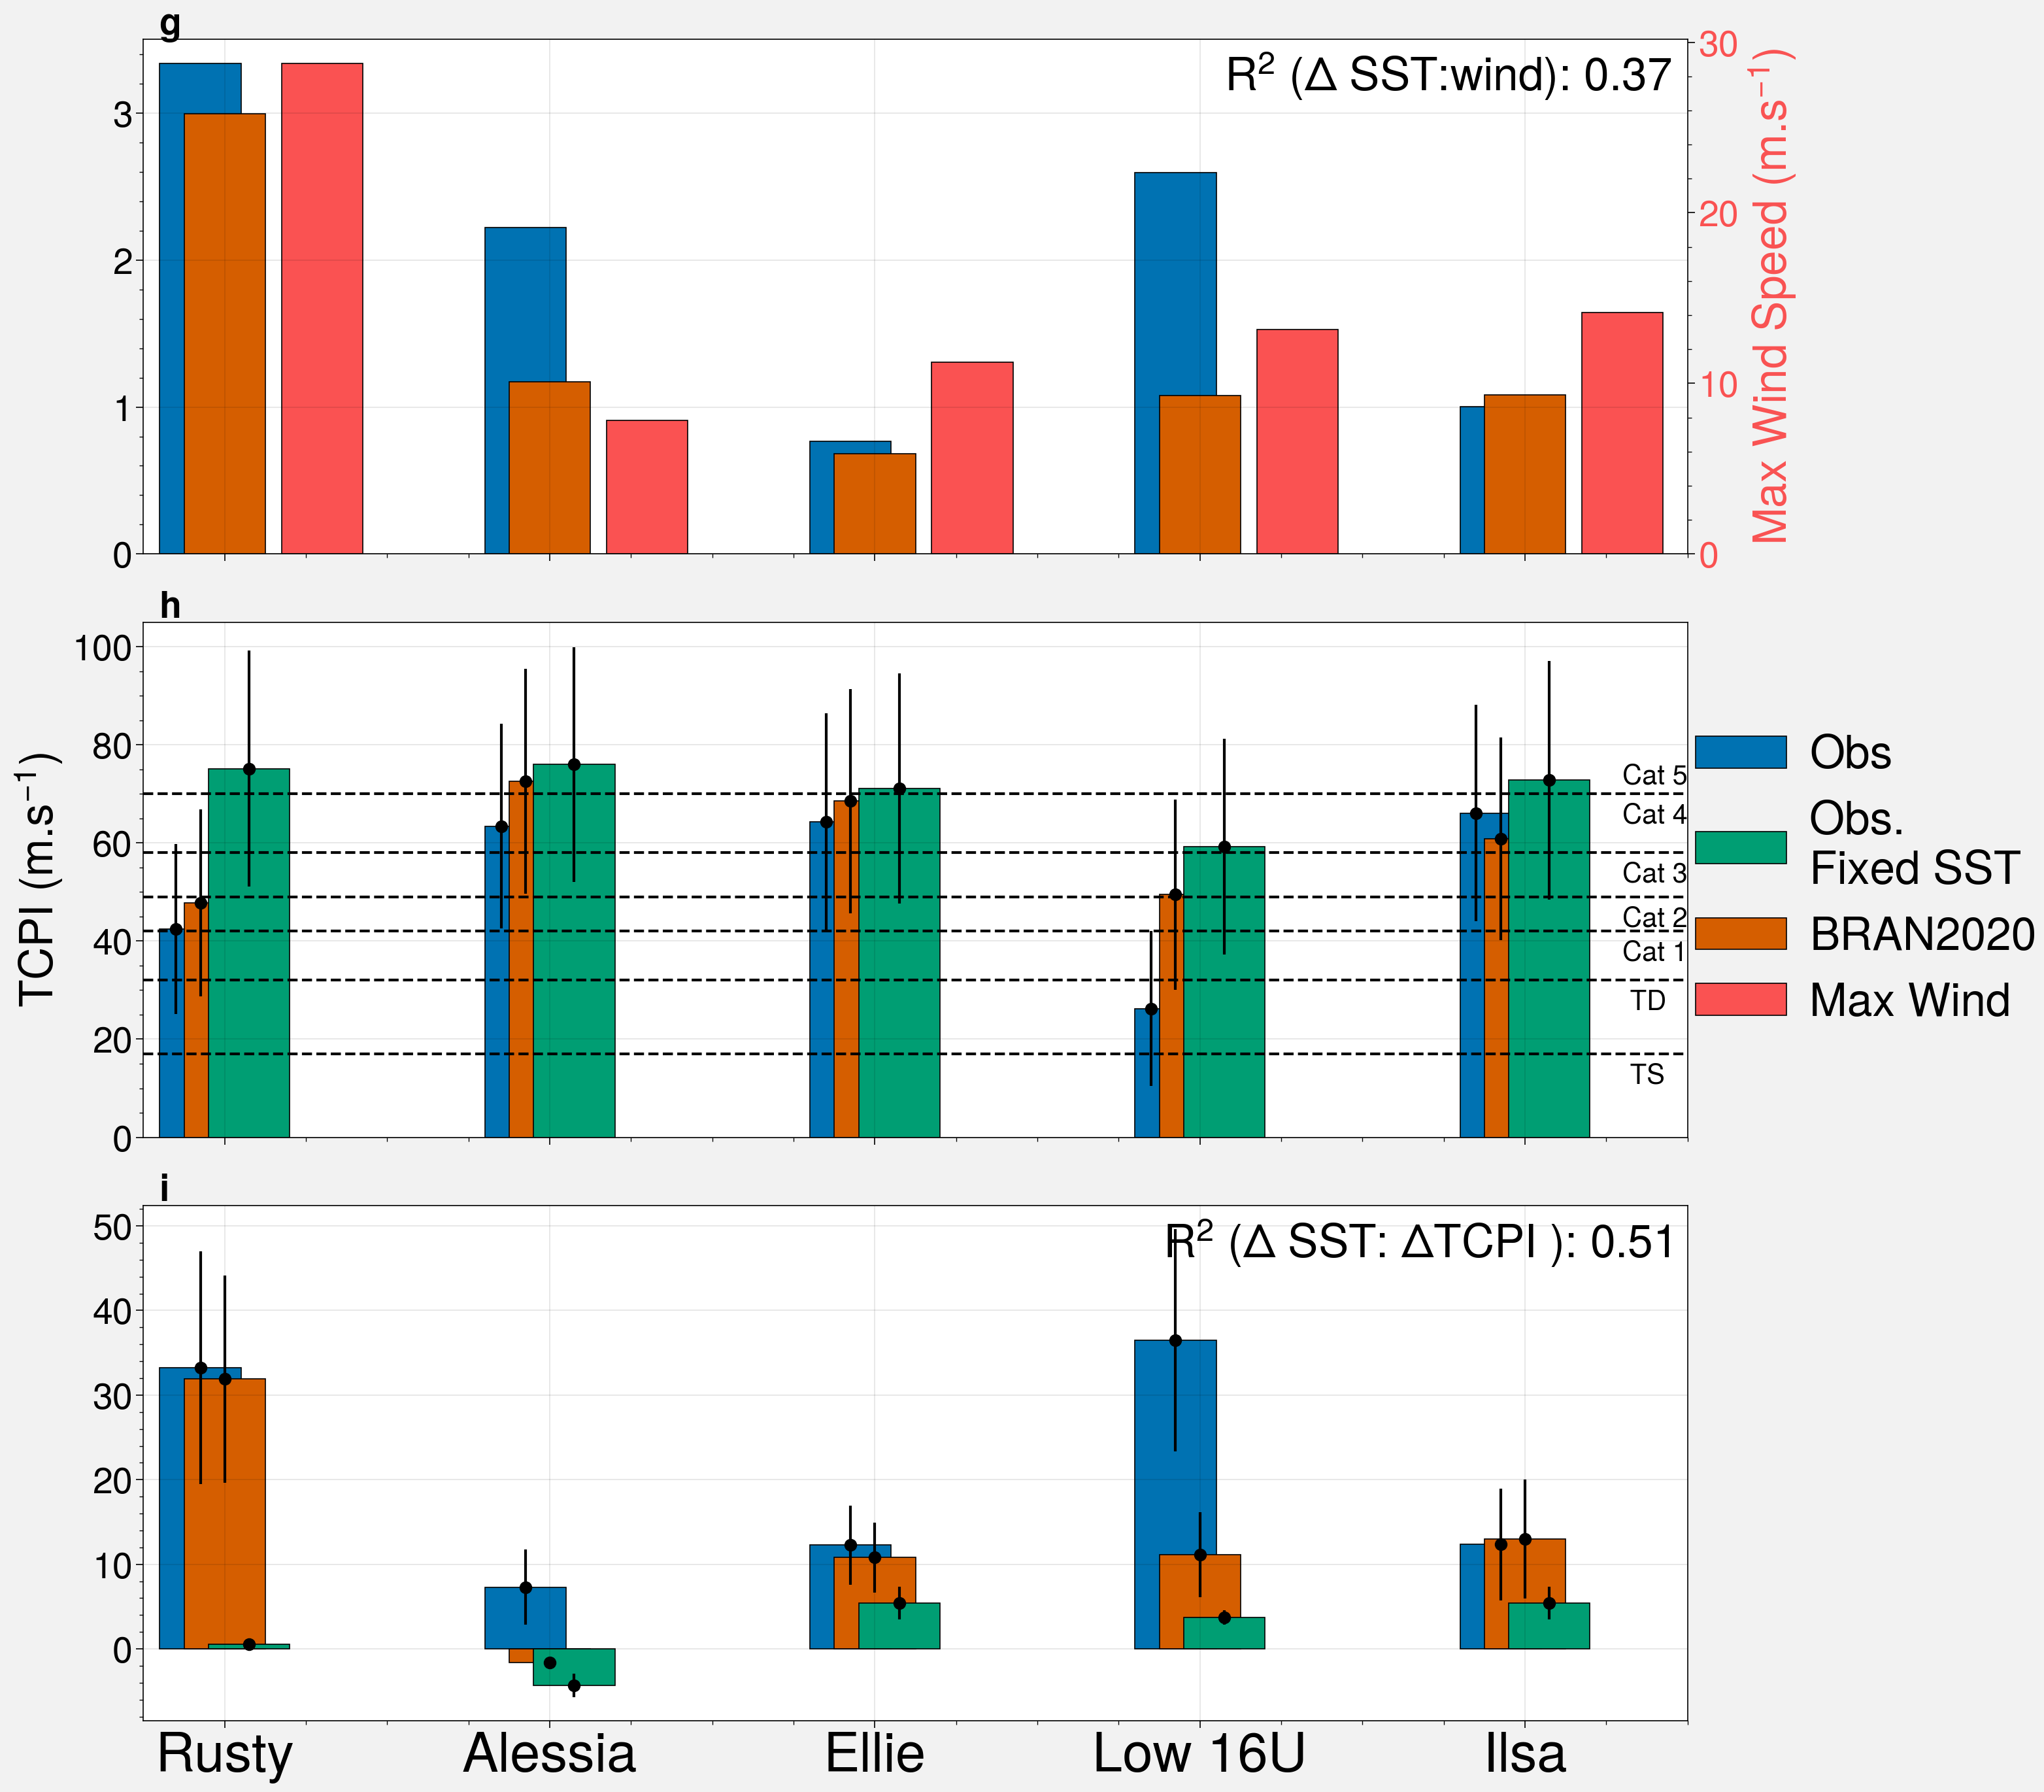

In [137]:
import proplot as proplot
import string
import matplotlib.colors as mcolors

saffir_simpson_winds = [17,32,42,49,58,70]
saffir_simpson_cat   = [' TS',' TD','Cat 1','Cat 2','Cat 3','Cat 4','Cat 5']

fig, axs = proplot.subplots(nrows=3,ncols=1,axwidth='30cm',axheight='10cm',proj=None ) #,2:None,3:None,4:None})
axs.format(abc=False,share=False) #, color='grey')



sst_cooling_obs = [] 
sst_cooling_BRAN = [] 
#storm_names = storm_names.values
for i_storm in storm_names:
    if i_storm !='Christine':
        sst_cooling_obs.append(storm_metrics_to_plot[i_storm]['sst_cooling_obs'])
        sst_cooling_BRAN.append(storm_metrics_to_plot[i_storm]['sst_cooling_BRAN'])
#sst_cooling_obs_no_christine = sst_cooling_obs.pop(2)
#sst_cooling_BRAN_no_christine = sst_cooling_BRAN.pop(2)
max_wind_speed = []
max_parm_wind_speed = []

for i_storm in storm_names:
    if i_storm !='Christine':
        max_wind_speed.append(storm_metrics_to_plot[i_storm]['max_era5_wind'])
        max_parm_wind_speed.append(max_parametric_wind_speed[i_storm])

R2_param = np.corrcoef(np.asarray(max_parm_wind_speed),np.asarray(sst_cooling_obs))[0,1]**2

axs[0,0].bar(np.arange(0,2*len(sst_cooling_obs),2)-0.15,sst_cooling_obs,width=0.25) #,color='tab:blue')
#ax.bar(np.arange(0,2*len(storm_names),2)+0.2,delta_vmax_fixed_sst,width=0.25)
axs[0,0].bar(np.arange(0,2*len(sst_cooling_obs),2),sst_cooling_BRAN,width=0.25) #,color='tab:orange') #,label='BRAN2020')
axs[0,0].set_ylabel(r'Max SST Cooling ($^{\circ}$C)',fontsize=25) #,color='red6')

axs[0,0].set_xticklabels([],size=30)
axs[0,0].set_yticks(np.arange(0,3))
axs[0,0].annotate(string.ascii_lowercase[6], xy=(0.01,1.01),xycoords='axes fraction',fontsize=20,weight='bold')
axs[0,0].set_yticks(np.arange(0,3.1,1))
axs[0,0].set_yticklabels(np.arange(0,3.1,1).astype('int'),fontsize=20)
#axs[0,0].set_ylabel(r'TCPI (m.s$^{-1}$)',fontsize=25) #,color='red6')
axs[0,0].annotate(r'R$^{2}$ ($\Delta$ SST:wind): ' + str(np.around(R2_param,2)), xy=(0.70,0.9),xycoords='axes fraction',fontsize=25)

ax_right = axs[0,0].twinx()




#ax_right.bar(np.arange(0,2*len(sst_cooling_obs),2)+0.4,max_wind_speed,width=0.25,color='red6')
wind_line = ax_right.bar(np.arange(0,2*len(sst_cooling_obs),2)+0.6,max_parm_wind_speed,width=0.25,color='red6')
ax_right.set_yticks(np.arange(0,30.1,10))
ax_right.set_yticklabels(np.arange(0,30.1,10).astype('int'),fontsize=20,color='red6')
ax_right.set_ylabel(r'Max Wind Speed (m.s$^{-1}$)',fontsize=25,color='red6')



vmax_obs = []
vmax_obs_p10 = []
vmax_obs_p90 = []

vmax_fixed_sst = [] 
vmax_fixed_sst_p90 = [] 

vmax_bran = []
vmax_bran_p90 = []

for i_storm in storm_names:
    if i_storm !='Christine':
        vmax_obs.append(storm_metrics_to_plot[i_storm]['vmin_obs_p50'])
        vmax_obs_p10.append(storm_metrics_to_plot[i_storm]['vmin_obs_p10'])
        vmax_obs_p90.append(storm_metrics_to_plot[i_storm]['vmin_obs_p90']*0.25)

        vmax_fixed_sst.append(storm_metrics_to_plot[i_storm]['vmin_fixed_sst_p50'])
        vmax_fixed_sst_p90.append(storm_metrics_to_plot[i_storm]['vmin_fixed_sst_p90'] * 0.25)

        vmax_bran.append(storm_metrics_to_plot[i_storm]['vmin_bran_p50'])
        vmax_bran_p90.append(storm_metrics_to_plot[i_storm]['vmin_bran_p90']*0.25)


axs[1,0].bar(np.arange(0,2*len(vmax_obs),2)-0.15,vmax_obs,width=0.25) #,color='tab:blue') #,label='Observations')
axs[1,0].errorbar(np.arange(0,2*len(vmax_obs),2)-0.3, vmax_obs, yerr=vmax_obs_p90,fmt="o", color="black")


#axs[1,0].bar(np.arange(0,2*len(vmax_obs_p10),2)-0.15,vmax_obs,width=0.25) #,color='tab:blue') #,label='Observations')

axs[1,0].bar(np.arange(0,2*len(vmax_obs),2),vmax_bran,width=0.25)
axs[1,0].errorbar(np.arange(0,2*len(vmax_obs),2)-0.15, vmax_bran, yerr=vmax_bran_p90,fmt="o", color="black")

axs[1,0].bar(np.arange(0,2*len(vmax_obs),2)+0.15,vmax_fixed_sst,width=0.25) #,color='tab:green') #,label='Obs. Fixed SST')
axs[1,0].errorbar(np.arange(0,2*len(vmax_obs),2)+0.15, vmax_fixed_sst, yerr=vmax_fixed_sst_p90,fmt="o", color="black")

for i_category in range(0,len(saffir_simpson_winds)):
    axs[1,0].axhline(saffir_simpson_winds[i_category],linestyle='--',color='black')
    axs[1,0].annotate(saffir_simpson_cat[i_category], xy=(2*len(vmax_obs)-1.4,saffir_simpson_winds[i_category]-6),xycoords='data',fontsize=15) #,weight='bold')
axs[1,0].annotate(saffir_simpson_cat[-1], xy=(2*len(vmax_obs)-1.4,saffir_simpson_winds[-1]+2),xycoords='data',fontsize=15)

axs[1,0].set_xticks(np.arange(0,2*len(storm_names),2))

axs[1,0].set_xticklabels([],size=30)
#ax.legend(loc='upper right',fontsize=25)
axs[1,0].annotate(string.ascii_lowercase[7], xy=(0.01,1.01),xycoords='axes fraction',fontsize=20,weight='bold')
axs[1,0].set_yticks(np.arange(0,100.1,20))
axs[1,0].set_yticklabels(np.arange(0,100.1,20).astype('int'),fontsize=20)
axs[1,0].set_ylabel(r'TCPI (m.s$^{-1}$)',fontsize=25) #,color='red6')




delta_vmax_obs = [] ax = sub

delta_vmax_obs_p90 = [] 

delta_vmax_fixed_sst = []
delta_vmax_fixed_sst_p90 = []

delta_vmax_bran = []
delta_vmax_bran_p90 = []

for i_storm in storm_names:
    if i_storm !='Christine':

        delta_vmax_obs.append(storm_metrics_to_plot[i_storm]['delta_vmax_obs_p50'])
        delta_vmax_obs_p90.append(storm_metrics_to_plot[i_storm]['delta_vmax_obs_p90']*0.5)

        delta_vmax_fixed_sst.append(storm_metrics_to_plot[i_storm]['delta_vmax_fixed_sst_p50'])
        delta_vmax_fixed_sst_p90.append(storm_metrics_to_plot[i_storm]['delta_vmax_fixed_sst_p90']*0.5)

        delta_vmax_bran.append(storm_metrics_to_plot[i_storm]['delta_vmax_BRAN_p50'])
        delta_vmax_bran_p90.append(storm_metrics_to_plot[i_storm]['delta_vmax_BRAN_p90'] *0.5)


lines1 =axs[2,0].bar(np.arange(0,2*len(delta_vmax_fixed_sst),2)-0.15,delta_vmax_obs,width=0.25,label='Obs')
axs[2,0].errorbar(np.arange(0,2*len(vmax_obs),2)-0.15, delta_vmax_obs, yerr=delta_vmax_obs_p90,fmt="o", color="black")

lines2 =axs[2,0].bar(np.arange(0,2*len(delta_vmax_fixed_sst),2),delta_vmax_bran,width=0.25,label='BRAN2020')
axs[2,0].errorbar(np.arange(0,2*len(vmax_obs),2), delta_vmax_bran, yerr=delta_vmax_bran_p90,fmt="o", color="black")

lines3 =axs[2,0].bar(np.arange(0,2*len(delta_vmax_fixed_sst),2)+0.15,delta_vmax_fixed_sst,width=0.25,label=r"Obs. Fixed SST")
axs[2,0].errorbar(np.arange(0,2*len(vmax_obs),2)+0.15, delta_vmax_fixed_sst, yerr=delta_vmax_fixed_sst_p90,fmt="o", color="black")


lines = (lines1,lines3,lines2,wind_line)
#labels = labels1+labels2+labels3
axs[2,0].set_ylabel('$\Delta$ TCPI (m.s$^{-1}$)',fontsize=25) #,color='red6')

axs[2,0].set_xticks(np.arange(0,2*len(storm_names),2))
axs[2,0].set_xticklabels([storm_names.iloc[0],storm_names.iloc[1],storm_names.iloc[3],'Low 16U',storm_names.iloc[5]],size=30)
axs[2,0].annotate(string.ascii_lowercase[8], xy=(0.01,1.01),xycoords='axes fraction',fontsize=20,weight='bold')
axs[2,0].set_yticks(np.arange(0,50.1,10))
axs[2,0].set_yticklabels(np.arange(0,50.1,10).astype('int'),fontsize=20)


axs[:].set_xlim([-0.5,9])
R2_delta_sst_delta_tcpi = np.corrcoef(np.asarray(sst_cooling_obs),np.asarray(delta_vmax_obs))[0,1]**2
axs[2,0].annotate(r'R$^{2}$ ($\Delta$ SST: $\Delta$TCPI ): ' + str(np.around(R2_delta_sst_delta_tcpi,2)), xy=(0.66,0.9),xycoords='axes fraction',fontsize=25)


axs[1,0].legend(lines,['Obs','Obs. \nFixed SST',"BRAN2020","Max Wind"],loc='r', ncols=1, frame=False,fontsize=25)
output_path = './Figures'
figure_file_name = 'SST_TCPI_Delta_TCPI_Obs_BRAN_with_error_and_scale'
fig.savefig(os.path.join(output_path,figure_file_name + '.png'),dpi=400)
fig.savefig(os.path.join(output_path,figure_file_name + '.pdf'),dpi=100)

In [80]:
storm_names.iloc[0]

'Rusty'

In [280]:
R2_era5 = np.corrcoef(np.asarray(max_wind_speed),np.asarray(sst_cooling_obs))[0,1]**2

In [28]:
wind_speed_dataset

<xarray.Dataset>
Dimensions:    (N_PROF: 28)
Coordinates:
  * N_PROF     (N_PROF) int64 518 519 520 521 522 523 ... 541 542 543 544 545
Data variables:
    wnd_spd    (N_PROF) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    pmin       (N_PROF) float64 ...
    LATITUDE   (N_PROF) float64 ...
    LONGITUDE  (N_PROF) float64 ...
    TIME       (N_PROF) datetime64[ns] ...

/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.
/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


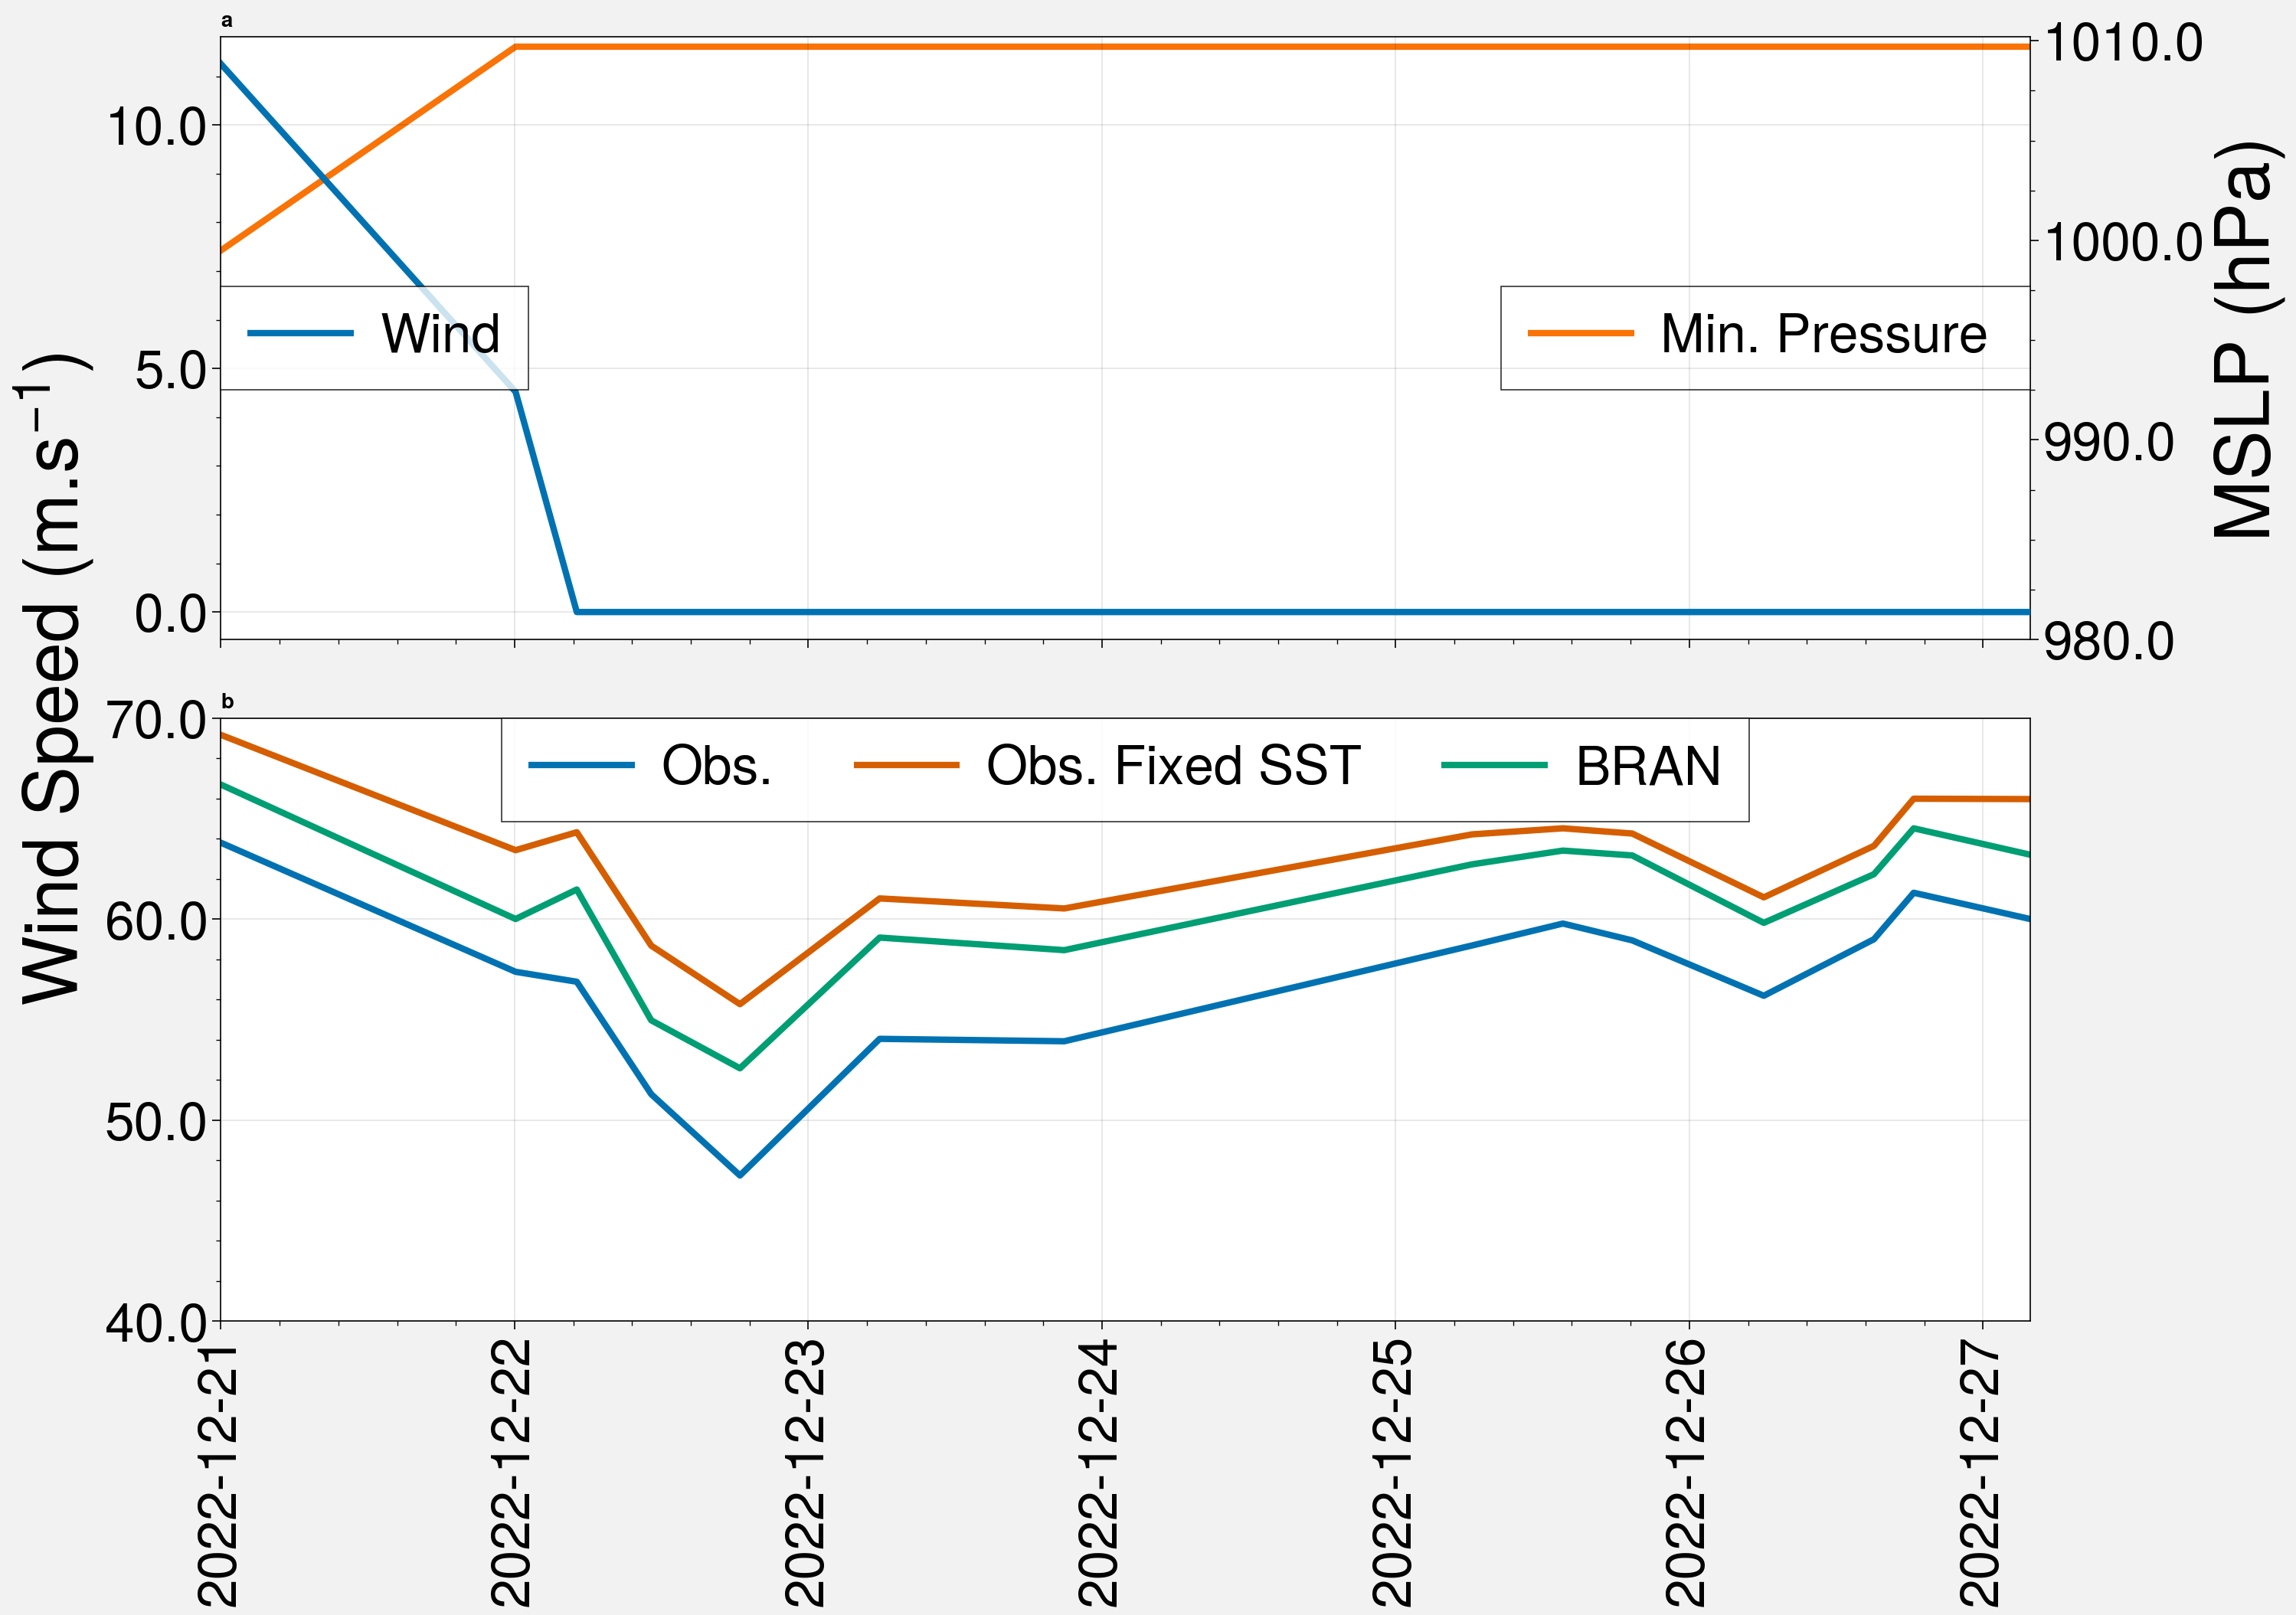

In [100]:
storm_name_to_get = 'Ellie'
turtle_id = str(cyclone_list_filtered.loc[cyclone_list_filtered['storm_name']==storm_name_to_get]['turtle_id'].values[0])

winds_file_name = storm_name_to_get + '_param_wind_speed_' + turtle_id


wind_speed_dataset = xarray.open_dataset(os.path.join(cyclone_winds_turtle_path,winds_file_name))
    



fig, axs = proplot.subplots(nrows=2,ncols=1,axwidth='30cm',axheight='10cm',proj=None ) #,2:None,3:None,4:None})
axs.format(abc=True,share=False) #, color='grey')

axs[0,:].plot(wind_speed_dataset['TIME'].values,wind_speed_dataset['wnd_spd'].values,linewidth=3.0,label='Wind')
ax2 = axs[0,:].twinx()


x=ax2.plot(wind_speed_dataset['TIME'].values,0.01*wind_speed_dataset['pmin'].values,'orange',linewidth=3.0,label='Min. Pressure ')
axs[0].legend(loc='center left',fontsize=25)
ax2.legend(loc='center right',fontsize=25)
axs[0].set_yticks(np.arange(0,10.1,5))
axs[0].set_yticklabels(np.arange(0,10.1,5),fontsize=25)
axs[0].set_ylabel('Wind Speed (m.s$^{-1}$)',fontsize=35)

ax2.set_yticks(np.arange(980,1011.1,10.1))
ax2.set_yticklabels(np.around(np.arange(980,1011.1,10.1),0),fontsize=25)
ax2.set_ylabel('MSLP (hPa)',fontsize=35)

#axs[0,:].plot(wind_speed_dataset['N_PROF'][idx_start_storm].values,wind_speed_dataset['wnd_spd'][idx_start_storm].values,'r*')
#axs[0,:].plot(wind_speed_dataset['N_PROF'][idx_end_storm].values,wind_speed_dataset['wnd_spd'][idx_end_storm].values,'r*')
axs[1,:].plot(storm_potential_intensities[storm_name_to_get]['time'] ,storm_potential_intensities[storm_name_to_get]['v_max_obs'][1,:],linewidth=3.0,label='Obs.')
axs[1,:].plot(storm_potential_intensities[storm_name_to_get]['time'] ,storm_potential_intensities[storm_name_to_get]['v_max_prestorm'][1,:],linewidth=3.0,label='Obs. Fixed SST')
axs[1,:].plot(storm_potential_intensities[storm_name_to_get]['time'] ,storm_potential_intensities[storm_name_to_get]['v_max_BRAN'][1,:],linewidth=3.0,label='BRAN')
axs[1,:].set_ylim([40,70])
axs[1].legend(loc='upper center',fontsize=25)
axs[1].set_yticks(np.arange(40,70.1,10))
axs[1].set_yticklabels(np.arange(40,70.1,10),fontsize=25)
axs[1].set_ylabel('TCPI (m.s$^{-1}$)',fontsize=35)
axs[1].set_xticks(pandas.date_range(wind_speed_dataset['TIME'].min().values,wind_speed_dataset['TIME'].max().values,freq='1D'))
axs[1].set_xticklabels(pandas.date_range(wind_speed_dataset['TIME'].min().values,wind_speed_dataset['TIME'].max().values,freq='1D').strftime("%Y-%m-%d"),fontsize=25)
axs[1,:].set_xlim([wind_speed_dataset['TIME'].min().values, np.datetime64('2022-12-28')])

output_path = './Figures'
figure_file_name = 'TCPI_Evolution_' + storm_name_to_get
fig.savefig(os.path.join(output_path,figure_file_name + '.png'),dpi=400)
fig.savefig(os.path.join(output_path,figure_file_name + '.pdf'),dpi=100)

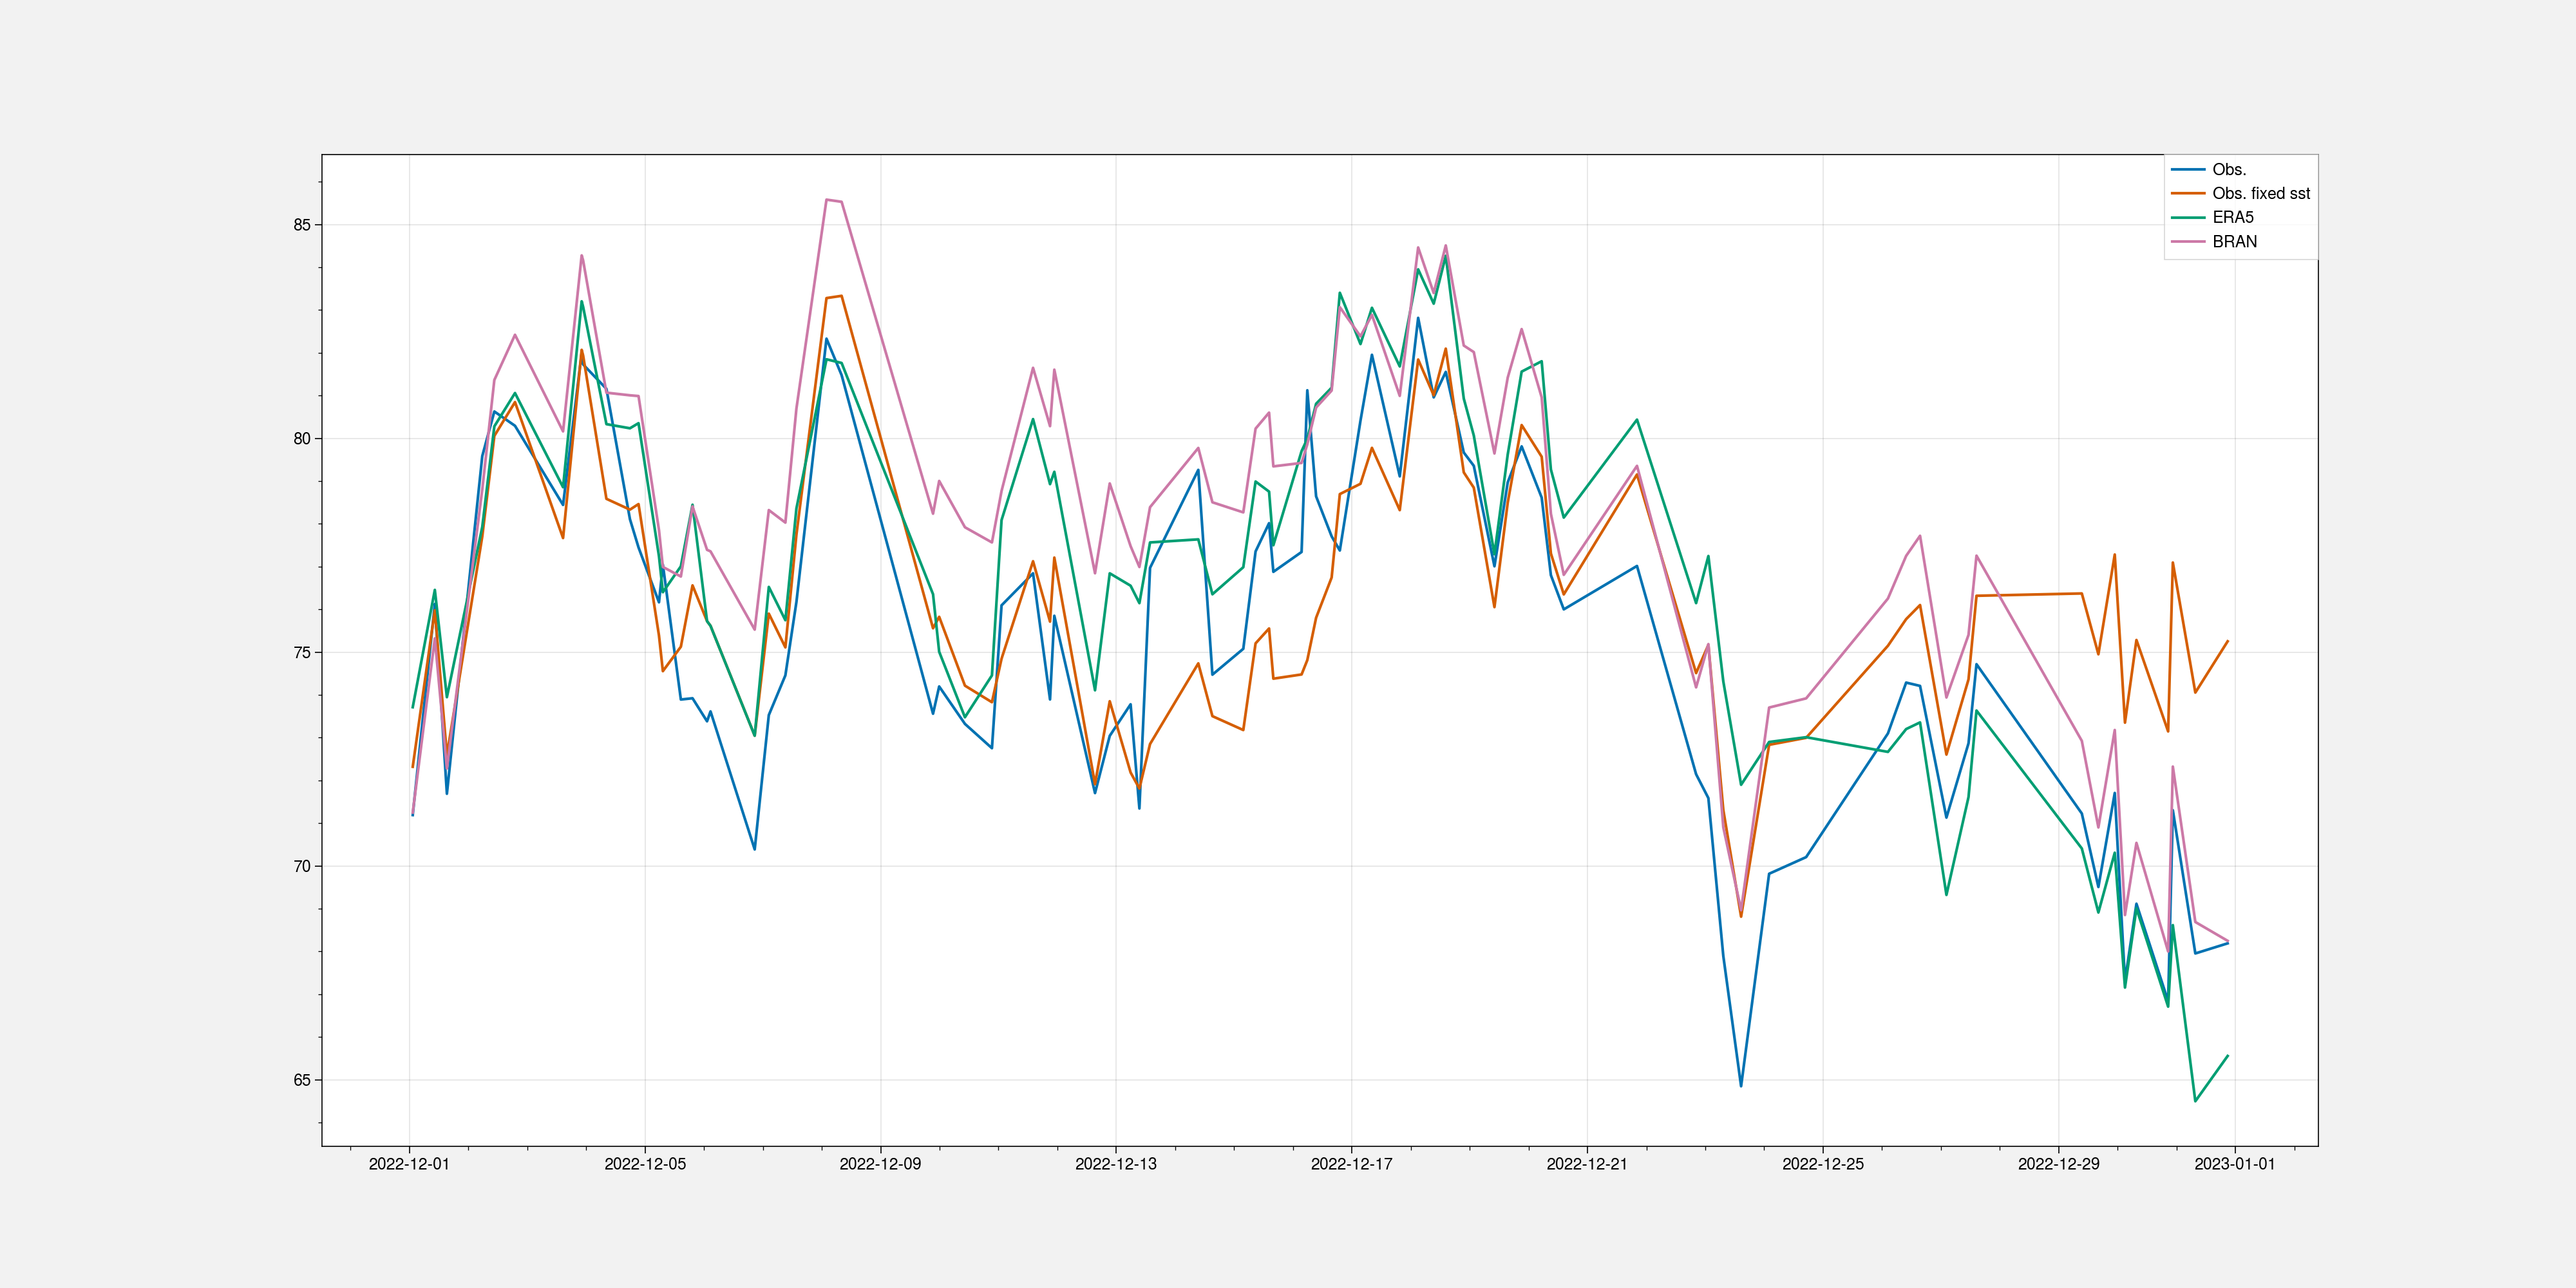

In [279]:
plt.figure(1,figsize=(20,10))
storm_name = 'Ellie'

plt.plot(storm_potential_intensities[storm_name]['time'] ,storm_potential_intensities[storm_name]['v_max_obs'],label='Obs.')
plt.plot(storm_potential_intensities[storm_name]['time'] ,storm_potential_intensities[storm_name]['v_max_prestorm'],label='Obs. fixed sst')

plt.plot(storm_potential_intensities[storm_name]['time'] ,storm_potential_intensities[storm_name]['v_max_era5'],label='ERA5')
plt.plot(storm_potential_intensities[storm_name]['time'] ,storm_potential_intensities[storm_name]['v_max_BRAN'],label='BRAN')
plt.legend()

In [112]:
SST_turtle[i_date]cyclone_winds

30.916000366210938

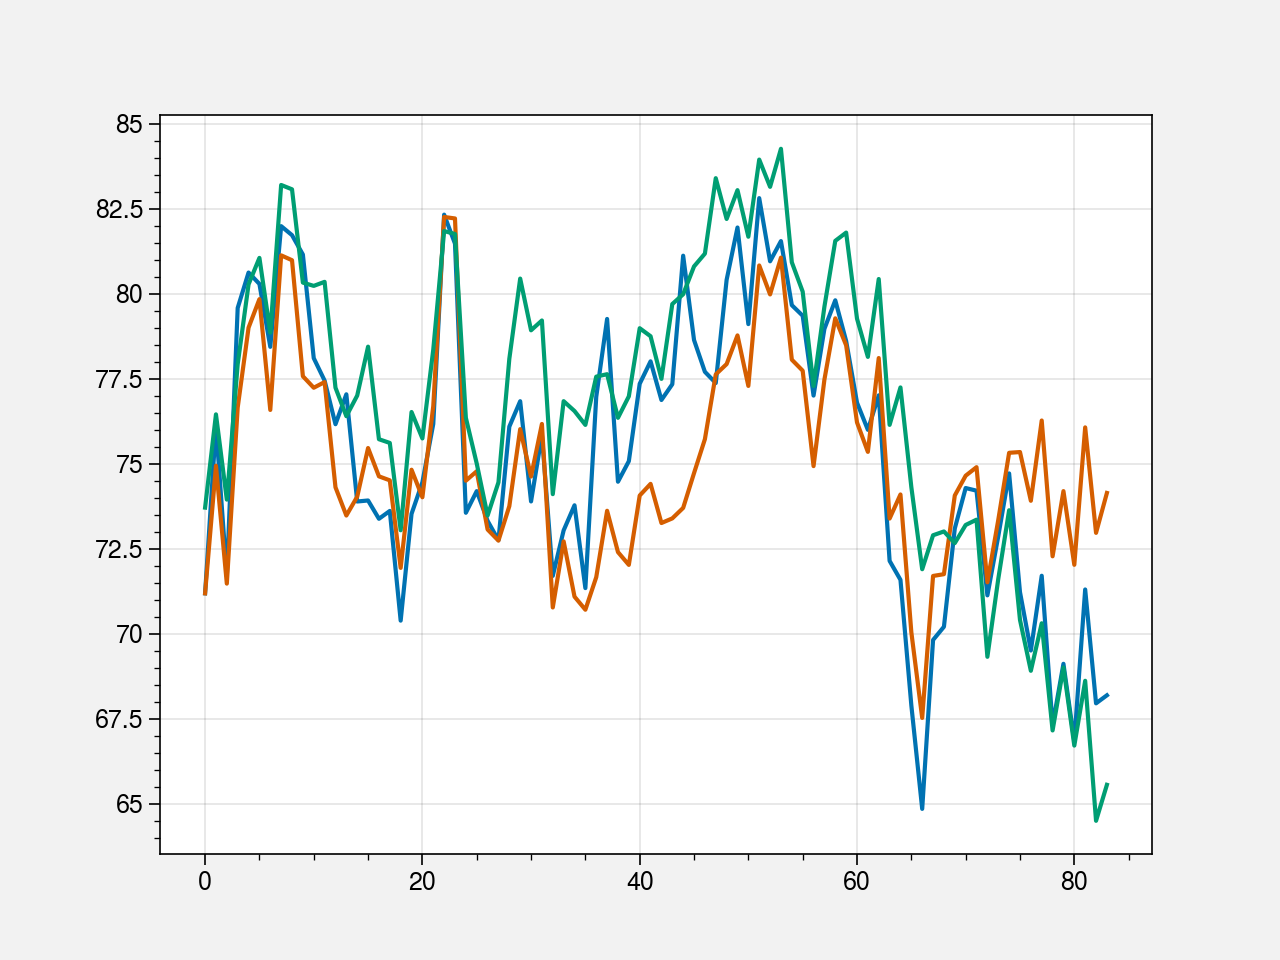

In [93]:
plt.plot(i_date['Ellie']['v_max_obs'])
plt.plot(storm_potential_intensities['Ellie']['v_max_prestorm'])
plt.plot(storm_potential_intensities['Ellie']['v_max_era5'])

#plt.plot(storm_potential_intensities['AU202223_16U']['v_max_obs'])


In [85]:
    storm_potential_intensities[i_storm]['v_max_obs']      = VMAX_turtle


In [42]:
np.abs(turtle_dates-date_to_get).astype('timedelta64[m]')<np.timedelta64(1,'m') 

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [34]:
turtle_idx.size

0

In [27]:
date_to_get

numpy.datetime64('2022-12-01T01:19:59.999995528')

In [29]:
ERA5_surface_for_storm['TIME'].values

array(['2022-12-01T01:19:59.999995528', '2022-12-01T10:19:59.999995528',
       '2022-12-01T15:14:59.999996650', '2022-12-02T05:40:00.000001113',
       '2022-12-02T10:35:00.000002235', '2022-12-02T18:59:59.999996650',
       '2022-12-03T14:34:59.999998886', '2022-12-03T22:10:00.000001113',
       '2022-12-03T22:44:59.999996650', '2022-12-04T08:15:00.000000000',
       '2022-12-04T17:49:59.999995528', '2022-12-04T21:19:59.999998886',
       '2022-12-05T05:40:00.000001113', '2022-12-05T07:15:00.000003349',
       '2022-12-05T14:34:59.999998886', '2022-12-05T19:19:59.999995528',
       '2022-12-06T01:15:00.000003349', '2022-12-06T02:40:00.000001113',
       '2022-12-06T20:40:00.000001113', '2022-12-07T02:25:00.000004471',
       '2022-12-07T09:10:00.000004471', '2022-12-07T13:40:00.000004471',
       '2022-12-08T01:55:00.000001113', '2022-12-08T08:04:59.999995528',
       '2022-12-09T21:19:59.999998886', '2022-12-09T23:49:59.999995528',
       '2022-12-10T10:19:59.999995528', '2022-12-10

In [33]:
turtle_dates [130:]

array(['2022-11-28T08:15:00.000000000', '2022-11-28T19:20:00.000038399',
       '2022-11-29T08:44:59.999971200', '2022-11-29T22:25:00.000019200',
       '2022-11-30T02:15:00.000000000', '2022-11-30T10:14:59.999971200',
       '2022-11-30T19:05:00.000009600', '2022-12-01T01:20:00.000038400',
       '2022-12-01T10:20:00.000038400', '2022-12-01T15:15:00.000028800',
       '2022-12-02T05:39:59.999990400', '2022-12-02T10:34:59.999980800',
       '2022-12-02T19:00:00.000028800', '2022-12-03T14:35:00.000009600',
       '2022-12-03T22:09:59.999990400', '2022-12-03T22:45:00.000028800',
       '2022-12-04T08:15:00.000000000', '2022-12-04T17:50:00.000038399',
       '2022-12-04T21:20:00.000009600', '2022-12-05T05:39:59.999990400',
       '2022-12-05T07:14:59.999971200', '2022-12-05T14:35:00.000009600',
       '2022-12-05T19:20:00.000038399', '2022-12-06T01:14:59.999971200',
       '2022-12-06T02:39:59.999990400', '2022-12-06T20:39:59.999990400',
       '2022-12-07T02:24:59.999961599', '2022-12-07

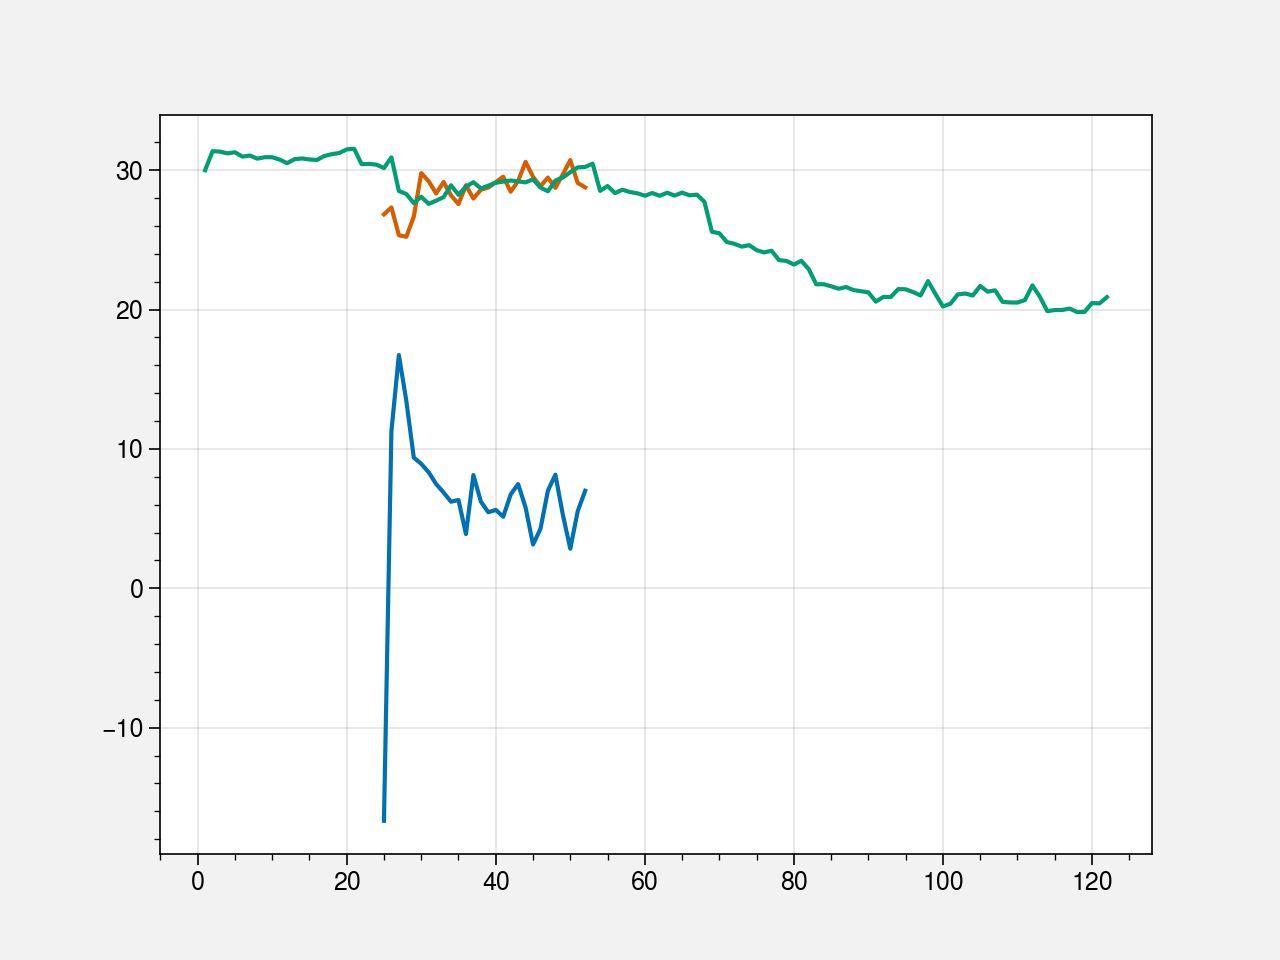

In [7]:
plt.plot(ERA5_surface_for_storm['N_PROF'].values,ERA5_surface_for_storm['10u'])
plt.plot(ERA5_profiles_for_storm['N_PROF'].values,ERA5_profiles_for_storm['t'][:,-1]-273.15)
plt.plot(turtle_dataset['profiles'],turtle_dataset['TEMP'][:,0].values)

In [21]:
sst

array([31.50371704])

Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!
Good inputs!

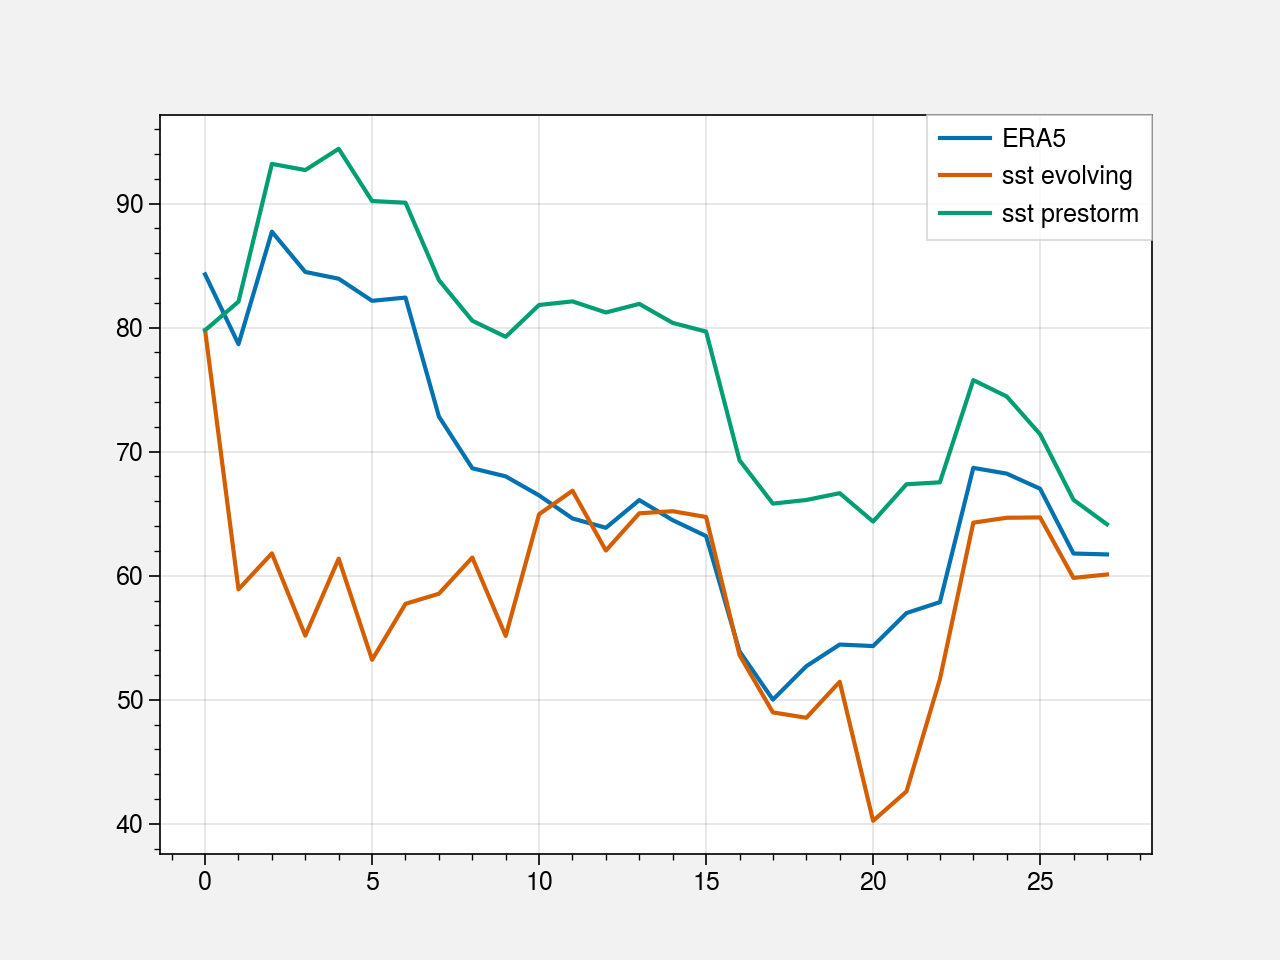

In [12]:
plt.plot(VMAX_era5,label='ERA5')
plt.plot(VMAX_turtle,label='sst evolving')
plt.plot(VMAX_turtle_fixed_sst,label='sst prestorm')
plt.legend()



In [30]:
VMAX_era5

array([84.29094015])

In [8]:
ERA5_for_storm

<xarray.Dataset>
Dimensions:    (N_PROF: 22, level: 37, profiles: 22, LONGITUDE: 122, LATITUDE: 122)
Coordinates:
  * N_PROF     (N_PROF) int64 0 1 2 3 4 5 6 7 8 9 ... 13 14 15 16 17 18 19 20 21
    levels     (level) int32 ...
  * level      (level) int32 1 2 3 5 7 10 20 30 ... 850 875 900 925 950 975 1000
  * profiles   (profiles) int32 26 27 28 29 30 31 32 33 ... 41 42 43 44 45 46 47
  * LONGITUDE  (LONGITUDE) float32 117.2 117.5 117.5 117.4 ... 120.4 120.4 120.6
  * LATITUDE   (LATITUDE) float32 -20.52 -20.5 -20.49 ... -19.71 -19.7 -19.68
Data variables:
    t          (N_PROF, level) float32 ...
    q          (N_PROF, level) float32 ...
    TIME       (profiles) datetime64[ns] ...